
## 📋 Overview: Andes Paleotopography Comparison

This notebook compares machine learning paleotopography predictions with published Andes reconstructions by:
1. **Loading Boschman et al. (2021)** paleo-DEM reconstructions (0-70 Ma)
2. **Extracting predictions** from deep learning model at same locations/times
3. **Validating with geochemical proxies** (Liu et al., 2024)
4. **Comparing with modern ETOPO** for present-day calibration
5. **Analyzing plate kinematic drivers** (subduction volume, trench migration)

**Study Region**: Andes Cordillera (15°N to 55°S)  
**Time Range**: 70 Ma to Present  
**Spatial Resolution**: ~0.1° (~20 km)  
**Required Time**: 5-10 mins for full analysis


In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import rasterio
import rioxarray
import geopandas as gpd
from shapely.ops import unary_union
from shapely.geometry import Point

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
import cmcrameri as cmc

from geopy.distance import geodesic
from scipy.signal import savgol_filter

from pyDTDM.BhuDM import *
from pyDTDM import *

import yaml
try:
    from yaml import CLoader as Loader
except ImportError:
    from yaml import Loader

import pyproj
# Point pyproj to the correct PROJ data directory
os.environ.setdefault("PROJ_LIB", "/Users/ssin4735/miniforge3/envs/EBMTest311/share/proj")
pyproj.datadir.set_data_dir(os.environ["PROJ_LIB"])


/Users/ssin4735/miniforge3/envs/EBMTest311/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/Users/ssin4735/miniforge3/envs/EBMTest311/lib/python3.11/site-packages/ptt/documentation.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


In [2]:
# Define the path to the configuration file
# config_file = "InputFiles/phase2NNR_paleotopography.yaml"
config_file = "InputFiles/Merdith1Ga.yaml"

# Open the configuration file and load parameters using YAML
with open(config_file) as f:
    PARAMS = yaml.load(f, Loader=Loader)  # Load parameters from YAML file using the specified Loader

# Print a confirmation message indicating the configuration file and parameters
print("––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– ")
print(" Parameters set from %s" % config_file)  # Display the path of the configuration file
print("––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– ")

––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– 
 Parameters set from InputFiles/Merdith1Ga.yaml
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– 


In [3]:
# Input Files 
MODEL_NAME=PARAMS['InputFiles']['plate_kinematics']['model_name']
MODEL_DIR = PARAMS['InputFiles']['plate_kinematics']['model_dir']  ## plate model
topology_filenames =[f"{MODEL_DIR}/{i}" for i in PARAMS['InputFiles']['plate_kinematics']['topology_files']]
rotation_filenames = [f"{MODEL_DIR}/{i}" for i in PARAMS['InputFiles']['plate_kinematics']['rotation_files']]
agegrid=PARAMS['InputFiles']['plate_kinematics']['agegrid']

ETOPO_FILE=PARAMS['InputFiles']['Raster']['ETOPO_FILE'] # ETOPO grid in meters (can be netCDf or GeoTiff)
ETOPO_Type=PARAMS['InputFiles']['Raster']['Raster_type']
coastlines = f"{MODEL_DIR }/{PARAMS['InputFiles']['plate_kinematics']['coastline_file']}"
static_polygon_file=f"{MODEL_DIR }/{PARAMS['InputFiles']['plate_kinematics']['static_polygon']}"
static_polygons = pygplates.FeatureCollection(static_polygon_file)
continents=f"{MODEL_DIR }/{PARAMS['InputFiles']['plate_kinematics']['continents']}"
print("––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– ")
print("Reading input file..... \n")
print("––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– ")
print(f"Plate Model: {MODEL_NAME} \n")
print(f"Model Directory: {MODEL_DIR} \n")
print(f"Coastlines: {coastlines} \n")
print(f"Continents: {continents} \n")
print(f"Static Polygons: {static_polygon_file} \n")
print(f"Model Agegrid: {agegrid} \n")
print(f"ETopo grid: {ETOPO_FILE}")
print("––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– \n")

––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– 
Reading input file..... 

––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– 
Plate Model: Merdith1Ga 

Model Directory: /Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions 

Coastlines: /Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/StaticGeometries/GSHHS_l_coastlines.shp 

Continents: /Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/shapes_continents.shp 

Static Polygons: /Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/shapes_static_polygons.shp 

Model Agegrid: //Volumes/SatyamData/Merdith1Ga/Merdith_etal_OPTIMISED_gplately2/seafloor_grid_output/SEAFLOOR_AGE/masked/ 

ETopo grid: /Users/ssin4735/Documents/PROJECT/PhD Project/Codes and Data/Part 2/A_DEEPTIMETOPO/Data/Smoothed ETopo.tif
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– 



In [4]:
Paleomag_ID=PARAMS['Parameters']['paleomag_id']
Mantle_ID=PARAMS['Parameters']['mantle_optimised_id']

#The initial positions of crustal points are evenly distributed within the designated region. 
# At mesh refinement level zero, the points are approximately 20 degrees apart.
# Each increase in the density level results in a halving of the spacing between points.
MESH_REFINEMENT_LEVEL=PARAMS['Parameters']['mesh_refinement_level']  # higher refinement level will take longer time to run for optimisation 
WINDOW_SIZE=int(PARAMS['Parameters']['time_window_size'])
Weighted=PARAMS['Parameters']['weighted_mean']


NETCDF_GRID_RESOLUTION=PARAMS['GridParameters']['grid_spacing']  # in degree
ZLIB=PARAMS['GridParameters']['compression']['zlib'] 
COMPLEVEL=PARAMS['GridParameters']['compression']['complevel'] 

FROM_TIME=int(PARAMS['TimeParameters']['time_max'])
TO_TIME=int(PARAMS['TimeParameters']['time_min'])
TIME_STEPS=int(PARAMS['TimeParameters']['time_step'])




parallel=PARAMS['Parameters']['number_of_cpus']### No of core to use or None for single core


print("––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– ")
print("The following parameters are set-")
print("––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– ")
print(f"Mantle Optmised Reference Frame ID: {Mantle_ID}")
print(f"Paleomagnetic Reference Frame ID: {Paleomag_ID} \n")

print(f"Moving Window Size: {WINDOW_SIZE}")
print(f"Weighted Mean: {Weighted}")

print(f"Mesh Refinement Level: {MESH_REFINEMENT_LEVEL}")
print(f"NetCDF GRID Resolution: {NETCDF_GRID_RESOLUTION}")
print(f"NetCDF Compression Level: {COMPLEVEL} \n")
print(f"Model Start Time: {FROM_TIME}")
print(f"Model End Time: {TO_TIME}")
print(f"Model Time Step: {TIME_STEPS}\n")


print(f"Number of CPU: {parallel}") # -1 means all the freely available CPU


print("––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– ")

––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– 
The following parameters are set-
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– 
Mantle Optmised Reference Frame ID: 0
Paleomagnetic Reference Frame ID: 0 

Moving Window Size: 25
Weighted Mean: True
Mesh Refinement Level: 9
NetCDF GRID Resolution: 0.1
NetCDF Compression Level: 5 

Model Start Time: 200
Model End Time: 0
Model Time Step: 1

Number of CPU: -1
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– 


In [5]:
# Output Directory
OUTPUT_FOLDER=PARAMS['OutputFiles']['output_dir']

DEFAULT_OUTPUT_CSV=os.path.join(OUTPUT_FOLDER,'CSV')
DEFAULT_OUTPUT_NetCDF=os.path.join(OUTPUT_FOLDER,'NetCDF') # folder to store output NetCDF grid
DEFAULT_OUTPUT_FIG=os.path.join(OUTPUT_FOLDER, 'Figure')




print("––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– ")
print(f"All the output will be saved in {OUTPUT_FOLDER}")
print("––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– ")
create_directory_if_not_exists(OUTPUT_FOLDER)
create_directory_if_not_exists(DEFAULT_OUTPUT_CSV)
create_directory_if_not_exists(DEFAULT_OUTPUT_NetCDF)
create_directory_if_not_exists(DEFAULT_OUTPUT_FIG)
print("––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– ")


––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– 
All the output will be saved in /Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/Paleotopography
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– 
Directory already exists: /Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/Paleotopography
Directory already exists: /Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/Paleotopography/CSV
Directory already exists: /Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/Paleotopography/NetCDF
Directory already exists: /Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/Paleotopography/Figure
––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––– 


In [6]:
## Lets define Plate Kinematics Model
PK=PlateKinematicsParameters(topology_filenames, 
                             rotation_filenames,
                             static_polygons,
                             agegrid=agegrid,
                             coastlines=coastlines,
                             continents=continents,
                             anchor_plate_id=Mantle_ID)
time = 0 #Ma
gplot = gplately.PlotTopologies(PK.model, coastlines=coastlines, continents=continents, time=time)

In [7]:
DEFAULT_OUTPUT_ANDES=f"{MODEL_DIR}/Andes"
create_directory_if_not_exists(DEFAULT_OUTPUT_ANDES)

Directory already exists: /Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/Andes


## Boschman 2021

<Axes: >

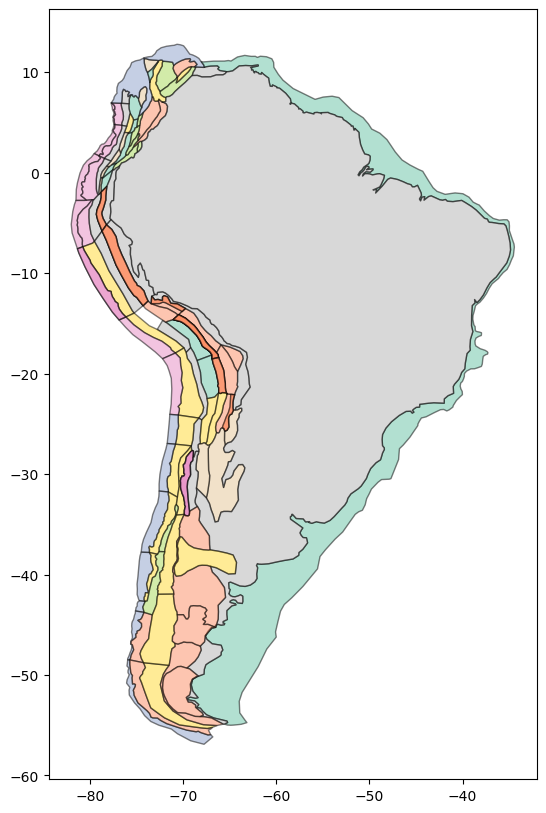

In [8]:
## Let get submain of Andes from Boschmann et al. 2021
Names=['Altiplano', 'Western Cordillera', 'Eastern Cordillera',
       'Precordillera/coastal cordillera/forearc', 'SubAndes',
       'Frontal Cordillera', 'Principal Cordillera', 'precordillera',
       'Principal Cordillera Patagonia',
       'Eastern Patagonia']

## Present day Polygon
present_day_polygon = gpd.read_file(f"{DEFAULT_OUTPUT_ANDES}/Boschman2021/2.reconstruction input/shapes/all/reconstructed_0.00Ma.shp",engine='fiona')
present_day_polygon = present_day_polygon.to_crs("EPSG:4326")
present_day_polygon.plot(column="NAME", edgecolor='black',cmap='Set2', figsize=(10, 10), alpha=0.5)


In [17]:
## We will create NorthernAndes polygon by merging all polygons whose centroid lies north of equator

# Load shapefile and reproject
gdfc = gpd.read_file(f"{DEFAULT_OUTPUT_ANDES}/Boschman2021/2.reconstruction input/shapes/all/reconstructed_0.00Ma.shp")
gdfc= gdfc.to_crs("EPSG:4326")  # Geographic for final output

gdf= gdfc[~gdfc['NAME'].str.match(r'^Forearc offshore \d+$', na=False)].copy()

# Reproject to projected CRS (e.g., UTM zone for Andes) for centroid calculation
projected_gdf = gdf.to_crs("EPSG:4326")  

# Filter polygons whose **centroid** lies north of the equator
north_gdf = gdf[projected_gdf.geometry.centroid.y > -1].copy()

# Fix invalid geometries using buffer(0)
north_gdf['geometry'] = north_gdf.buffer(0)

# Merge using the new `union_all` method (as of shapely 2.0+)
merged_geom = north_gdf.geometry.union_all()

# Create a new GeoDataFrame
northern_andes = gpd.GeoDataFrame({'NAME': ['Northern Andes'], 'geometry': [merged_geom]}, crs="EPSG:4326")

#  Remove all names that start with "Forearc offshore"
# northern_andes_cleaned = northern_andes[~northern_andes['NAME'].str.match(r'^Forearc offshore \d+$', na=False)].copy()

# Print confirmation
print("NorthernAndes polygon successfully created.")


NorthernAndes polygon successfully created.


/var/folders/qr/01bxwnvn05s319mx5c07sd7w0000gp/T/ipykernel_5842/1244064491.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



In [19]:
northern_andes_name=north_gdf['NAME'].unique()
northern_andes_name

array(['Garzon Massif 1', 'Garzon Massif 2', 'Eastern Cordillera 1',
       'Eastern Cordillera 2', 'Maracaibo', 'Merida/Venezuelan Andes 1',
       'Merida/Venezuelan Andes 2', 'Santa Marta Massif', 'Falcon',
       'Perija', 'Venezuelan Coastal Ranges', 'Central Cordillera 1',
       'Central Cordillera 2', 'Central Cordillera 3',
       'Central Cordillera 4', 'Central Cordillera 5', 'Quebradagrande 1',
       'Quebradagrande 2', 'Quebradagrande 3', 'Quebradagrande 4',
       'Western Cordillera 1', 'Western Cordillera 2',
       'Western Cordillera 3', 'Western Cordillera 4', 'Magdalena valley',
       'Magdalena Basin 1', 'Magdalena Basin 2', 'San Lucas',
       'Cesar Basin'], dtype=object)

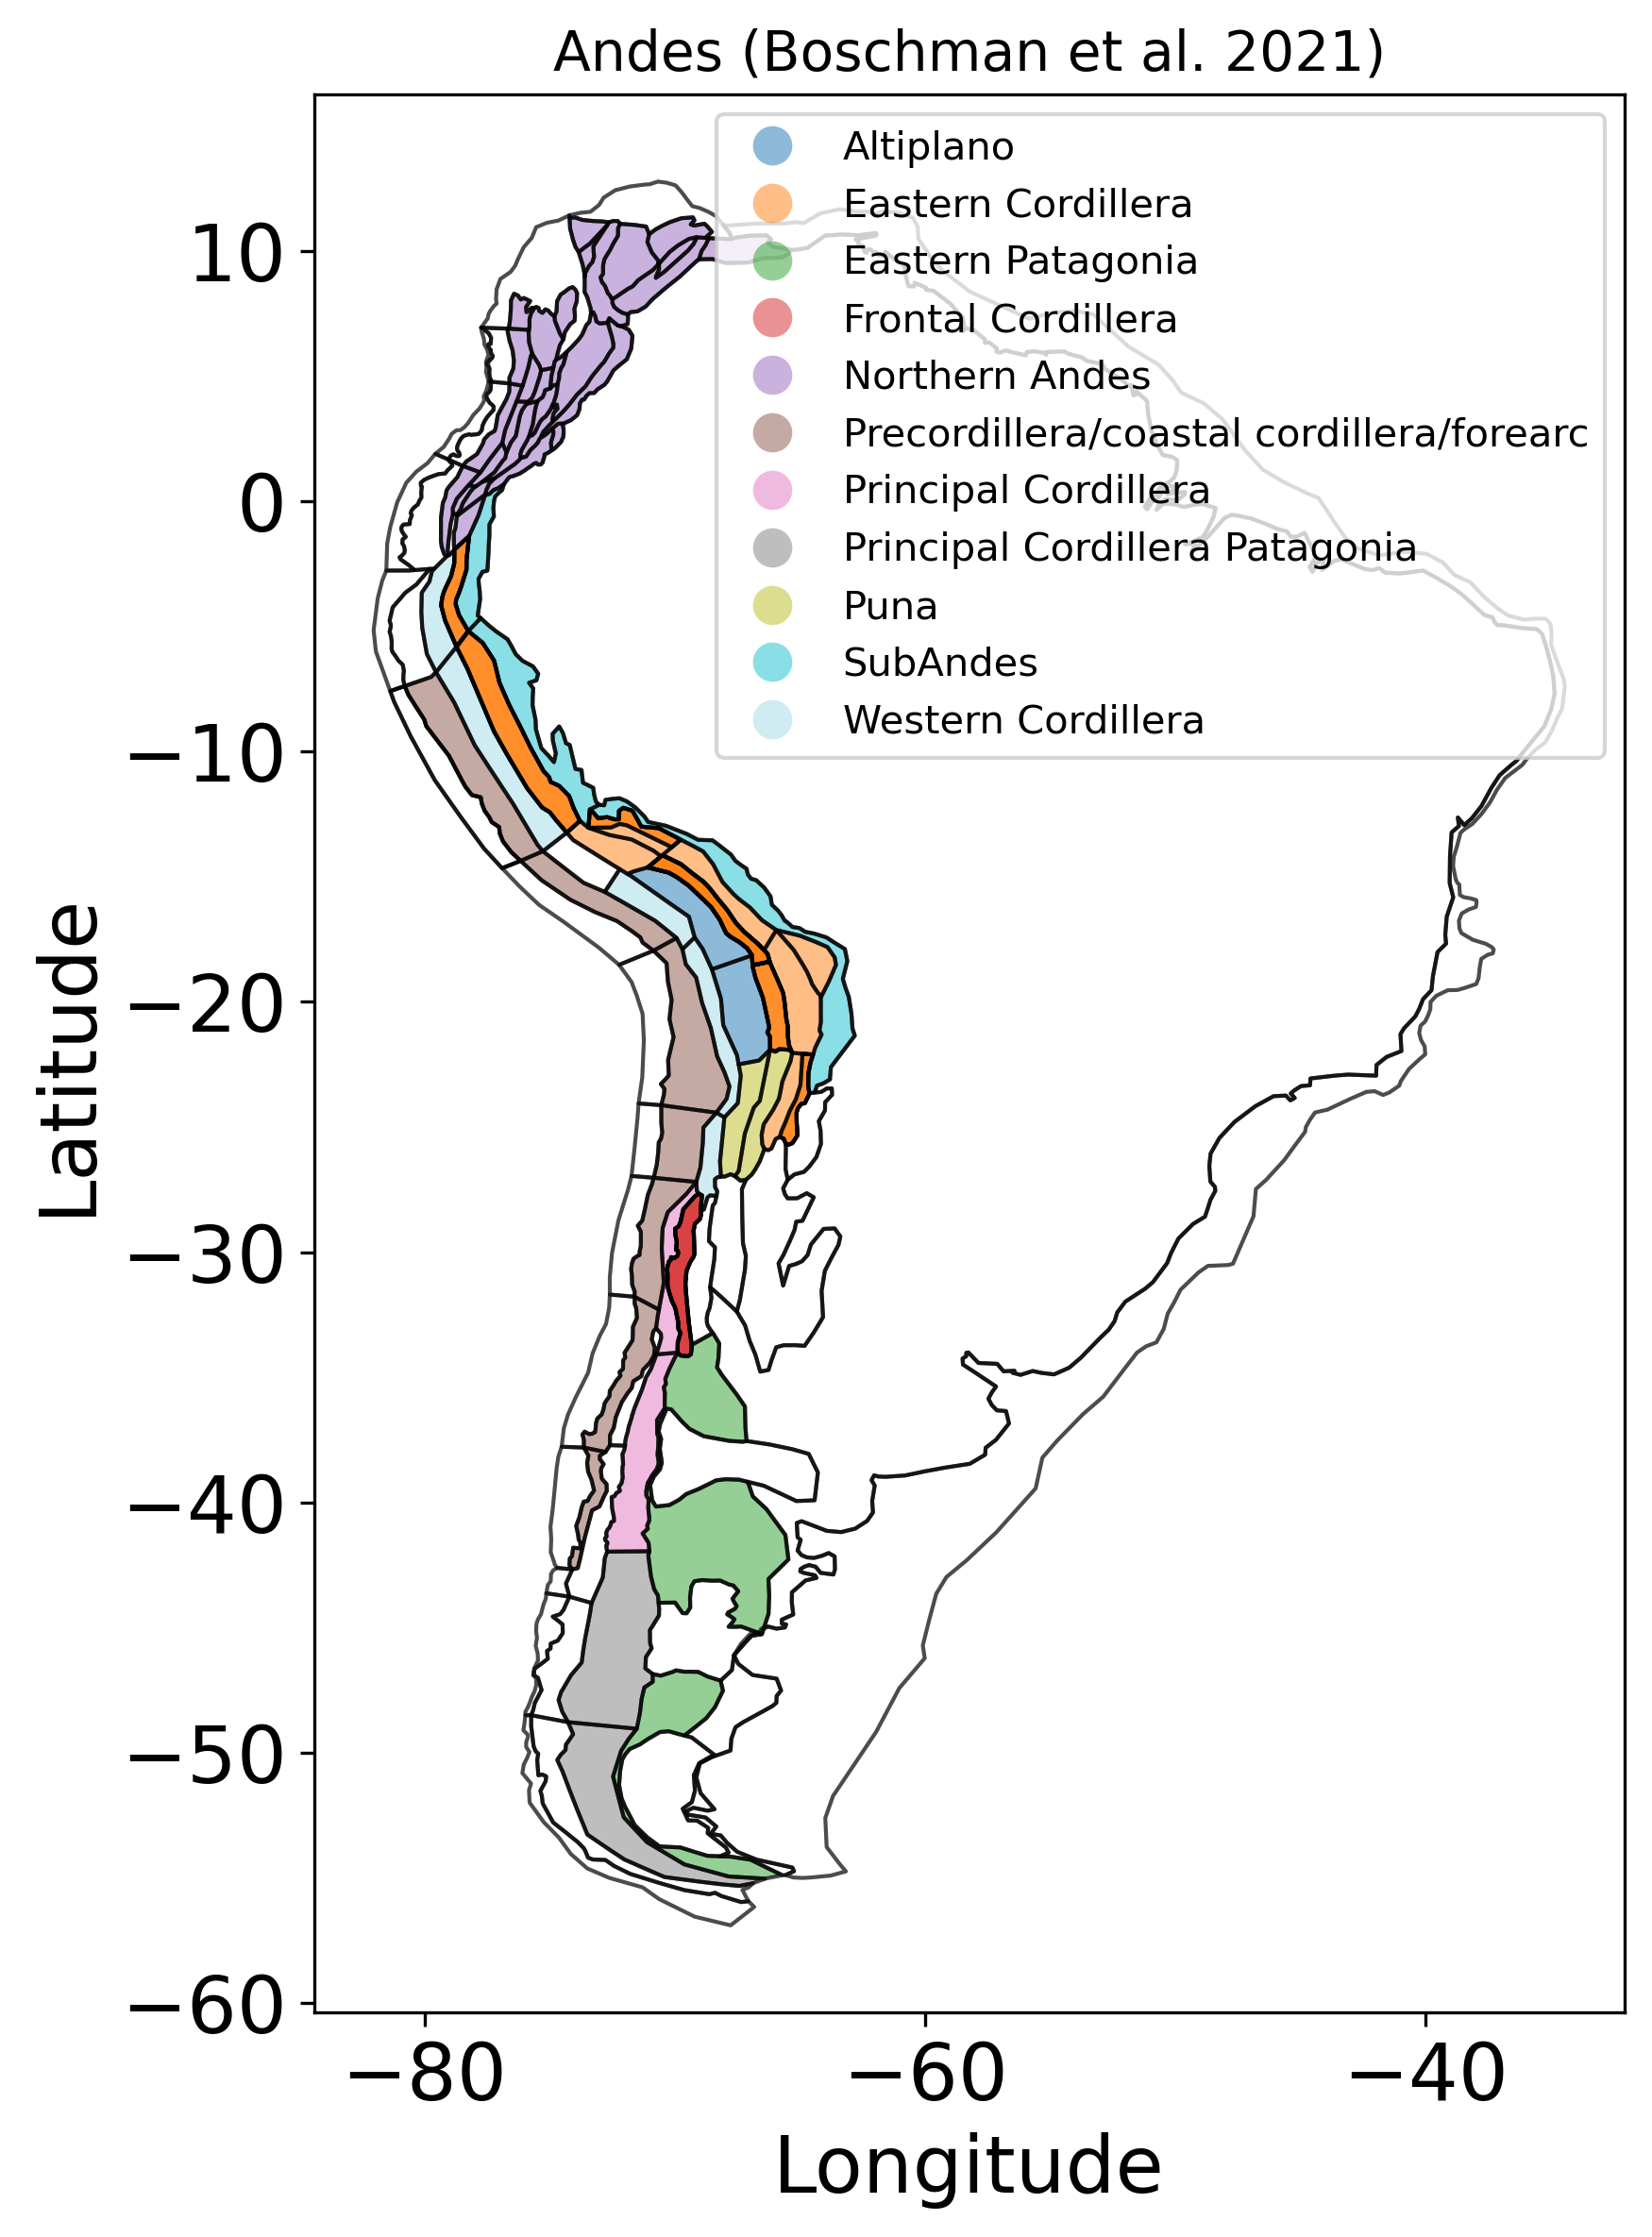

In [10]:

# Load shapefile and reproject
present_day_polygon = gpd.read_file(f"{DEFAULT_OUTPUT_ANDES}/Boschman2021/2.reconstruction input/shapes/all/reconstructed_0.00Ma.shp")
present_day_polygon = present_day_polygon.to_crs("EPSG:4326")

# Define target subdomains
Names = [
    'Altiplano', 'Western Cordillera', 'Eastern Cordillera',
    'Precordillera/coastal cordillera/forearc', 'SubAndes',
    'Frontal Cordillera', 'Principal Cordillera',
    'Principal Cordillera Patagonia', 'Eastern Patagonia','Puna'
]

# Filter polygons
present_day_polygonc = present_day_polygon[present_day_polygon['NAME'].isin(Names)].copy()
present_day_polygonc =pd.concat([present_day_polygonc, northern_andes], ignore_index=True)

# Plot with legend
fig, ax = plt.subplots(figsize=(8, 8),dpi=300)
present_day_polygonc.plot(column="NAME", cmap='tab20', alpha=0.5, ax=ax, legend=True)
# northern_andes.plot(ax=ax,edgecolor='black', facecolor='lightgreen',label='Northern Andes',figsize=(10, 10))
present_day_polygon.plot(ax=ax,edgecolor='black',facecolor='none',figsize=(10, 10), alpha=0.7)
# Customize plot
ax.set_title("Andes (Boschman et al. 2021)", fontsize=14)
ax.set_xlabel("Longitude", fontsize=20)
ax.set_ylabel("Latitude", fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_aspect('equal')
# plt.legend()
plt.tight_layout()
plt.savefig(f"{DEFAULT_OUTPUT_FIG}/Andes_PresentDay_Polygon.png", dpi=300)
plt.show()


In [13]:


# Initialize empty list to hold filtered dataframes
all_data = []

for reconstruction_time in range(0, 71):
    print(f"Processing {reconstruction_time} Ma")

    # Load shapefile and filter by NAME
    poly = gpd.read_file(f"{DEFAULT_OUTPUT_ANDES}/Boschman2021/2.reconstruction input/shapes/all/reconstructed_{reconstruction_time}.00Ma.shp")
    poly = poly.to_crs("EPSG:4326")
    # poly = poly[poly.NAME.isin(NAME)]  # NAME should be predefined list

    # Open raster
    dataset_elevation = rasterio.open(f"{DEFAULT_OUTPUT_ANDES}/Boschman2021/4.rasters_reconstruction_PREFERRED/{reconstruction_time}_Ma.grd")
    elevationdf = dataset_elevation.read(1)
    
    # Create coordinate meshgrid
    xs, ys = np.meshgrid(
        np.linspace(dataset_elevation.bounds.left, dataset_elevation.bounds.right, dataset_elevation.width),
        np.linspace(dataset_elevation.bounds.top, dataset_elevation.bounds.bottom, dataset_elevation.height)
    )
    
    # Flatten arrays and create GeoDataFrame
    flat_x = xs.flatten()
    flat_y = ys.flatten()
    flat_z = elevationdf.flatten()

    elevation_gdf = gpd.GeoDataFrame({
        "x": flat_x,
        "y": flat_y,
        "elevation": flat_z,
        "time": reconstruction_time
    }, geometry=gpd.points_from_xy(flat_x, flat_y), crs="EPSG:4326")

    # Spatial join: keep only points within polygon(s)
    clipped = gpd.sjoin(elevation_gdf, poly, predicate="within", how="inner")

    # Append to list
    all_data.append(clipped[["x", "y", "elevation", "time",'NAME']])

# Merge all time steps into one DataFrame
merged_df = pd.concat(all_data, ignore_index=True)


Processing 0 Ma
Processing 1 Ma
Processing 2 Ma
Processing 3 Ma
Processing 4 Ma
Processing 5 Ma
Processing 6 Ma
Processing 7 Ma
Processing 8 Ma
Processing 9 Ma
Processing 10 Ma
Processing 11 Ma
Processing 12 Ma
Processing 13 Ma
Processing 14 Ma
Processing 15 Ma
Processing 16 Ma
Processing 17 Ma
Processing 18 Ma
Processing 19 Ma
Processing 20 Ma
Processing 21 Ma
Processing 22 Ma
Processing 23 Ma
Processing 24 Ma
Processing 25 Ma
Processing 26 Ma
Processing 27 Ma
Processing 28 Ma
Processing 29 Ma
Processing 30 Ma
Processing 31 Ma
Processing 32 Ma
Processing 33 Ma
Processing 34 Ma
Processing 35 Ma
Processing 36 Ma
Processing 37 Ma
Processing 38 Ma
Processing 39 Ma
Processing 40 Ma
Processing 41 Ma
Processing 42 Ma
Processing 43 Ma
Processing 44 Ma
Processing 45 Ma
Processing 46 Ma
Processing 47 Ma
Processing 48 Ma
Processing 49 Ma
Processing 50 Ma
Processing 51 Ma
Processing 52 Ma
Processing 53 Ma
Processing 54 Ma
Processing 55 Ma
Processing 56 Ma
Processing 57 Ma
Processing 58 Ma
Process

In [14]:
merged_df.dropna()
merged_df.to_csv(f"{DEFAULT_OUTPUT_ANDES}/Boschmann2021_Andes_elevation.csv", index=False)

In [11]:
## To avoid re-running the above cell 
merged_df= pd.read_csv(f"{DEFAULT_OUTPUT_ANDES}/Boschmann2021_Andes_elevation.csv")

### Deep Learning Model

In [21]:
ml_model_name = 'DL'
# Initialize empty list to hold filtered dataframes
all_data_singh = []

for reconstruction_time in range(0, 71):
    print(f"Processing {reconstruction_time} Ma")

    # Load shapefile and filter by NAME

    poly = gpd.read_file(f"{DEFAULT_OUTPUT_ANDES}/Boschman2021/Singh++/Reconstructed_Andes_{reconstruction_time}.shp")
    
    poly = poly.to_crs("EPSG:4326")

    # Open raster
    dl_topo_dir = f"{DEFAULT_OUTPUT_NetCDF}/{ml_model_name}_Model_{WINDOW_SIZE}_MANTLE_interpolated"

    raster_file1  = f"{dl_topo_dir}/{ml_model_name}_Model_{MODEL_NAME}_{reconstruction_time}.nc"

    dataset_elevation = rasterio.open(raster_file1)
    elevationdf = dataset_elevation.read(1)
    
    # Create coordinate meshgrid
    xs, ys = np.meshgrid(
        np.linspace(dataset_elevation.bounds.left, dataset_elevation.bounds.right, dataset_elevation.width),
        np.linspace(dataset_elevation.bounds.top, dataset_elevation.bounds.bottom, dataset_elevation.height)
    )
    
    # Flatten arrays and create GeoDataFrame
    flat_x = xs.flatten()
    flat_y = ys.flatten()
    flat_z = elevationdf.flatten()

    elevation_gdf = gpd.GeoDataFrame({
        "x": flat_x,
        "y": flat_y,
        "elevation": flat_z,
        "time": reconstruction_time
    }, geometry=gpd.points_from_xy(flat_x, flat_y), crs="EPSG:4326")

    # Spatial join: keep only points within polygon(s)
    clipped = gpd.sjoin(elevation_gdf, poly, predicate="within", how="inner")

    # Append to list
    all_data_singh .append(clipped[["x", "y", "elevation", "time", 'NAME']])

# Merge all time steps into one DataFrame
merged_df_singh  = pd.concat(all_data_singh, ignore_index=True)


Processing 0 Ma
Processing 1 Ma
Processing 2 Ma
Processing 3 Ma
Processing 4 Ma
Processing 5 Ma
Processing 6 Ma
Processing 7 Ma
Processing 8 Ma
Processing 9 Ma
Processing 10 Ma
Processing 11 Ma
Processing 12 Ma
Processing 13 Ma
Processing 14 Ma
Processing 15 Ma
Processing 16 Ma
Processing 17 Ma
Processing 18 Ma
Processing 19 Ma
Processing 20 Ma
Processing 21 Ma
Processing 22 Ma
Processing 23 Ma
Processing 24 Ma
Processing 25 Ma
Processing 26 Ma
Processing 27 Ma
Processing 28 Ma
Processing 29 Ma
Processing 30 Ma
Processing 31 Ma
Processing 32 Ma
Processing 33 Ma
Processing 34 Ma
Processing 35 Ma
Processing 36 Ma
Processing 37 Ma
Processing 38 Ma
Processing 39 Ma
Processing 40 Ma
Processing 41 Ma
Processing 42 Ma
Processing 43 Ma
Processing 44 Ma
Processing 45 Ma
Processing 46 Ma
Processing 47 Ma
Processing 48 Ma
Processing 49 Ma
Processing 50 Ma
Processing 51 Ma
Processing 52 Ma
Processing 53 Ma
Processing 54 Ma
Processing 55 Ma
Processing 56 Ma
Processing 57 Ma
Processing 58 Ma
Process

In [23]:
merged_df_singh.to_csv(f"{DEFAULT_OUTPUT_ANDES}/Singh2025_Andes_elevation.csv", index=False)

In [12]:
## To avoid re-running the above cell 
merged_df_singh=pd.read_csv(f"{DEFAULT_OUTPUT_ANDES}/Singh2025_Andes_elevation.csv")

## Geochemical Proxies from Liu et al., 2024

In [13]:
### Data from Liu et al., 2024

paleoelevations_ld=pd.read_csv(f"{MODEL_DIR}/GeochemicalData/paleoelevations_global.csv")
columns=['la_yb_elevation', 'ce_yb_elevation', 'lu_hf_elevation',
       'nd_yb_elevation', 'la_y_elevation', 'nb_y_elevation',
       'sm_yb_elevation', 'ce_y_elevation', 'nd_y_elevation',
       'th_yb_elevation', 'hf_ppm_elevation', 'la_sm_elevation',
       'gd_yb_elevation', 'ba_v_elevation', 'mno_elevation', 'k2o_elevation',
       'zr_y_elevation', 'ba_sc_elevation', 'a_elevation', 'nb_yb_elevation',
       'dy_yb_elevation', 'a_cao_elevation', 'th_y_elevation', 'cao_elevation',
       'rb_ppm_elevation', 'ni_sc_elevation', 'sc_ppm_elevation',
       'ga_ppm_elevation', 'pb_ppm_elevation', 'ba_ppm_elevation',
       'u_ppm_elevation', 'feo_tot_elevation', 'cr_sc_elevation',
       'ni_ppm_elevation', 'sr_y_elevation', 'sr_ppm_elevation',
       'zr_ti_elevation', 'ni_v_elevation', 'cr_v_elevation']

paleoelevations_ld["Elevation (Median)"]=paleoelevations_ld[columns].median(axis=1)
paleoelevations_ld["Elevation (Median)"]=paleoelevations_ld["Elevation (Median)"].astype('float')
paleoelevations_ld["Elevation (Std)"]=paleoelevations_ld[columns].std(axis=1)
paleoelevations_ld["Elevation (Std)"]=paleoelevations_ld["Elevation (Std)"].astype('float')

paleoelevations_ld_gdf= gpd.GeoDataFrame(
    paleoelevations_ld,
    geometry=gpd.points_from_xy(paleoelevations_ld["Longitude"], paleoelevations_ld["Latitude"]),
    crs="EPSG:4326"
)

clipped_ld = gpd.sjoin(paleoelevations_ld_gdf, present_day_polygon, predicate="within", how="inner")
clipped_ld=clipped_ld[clipped_ld["age"]<=80]

## Present Day ETopo

In [14]:


import rasterio
from rasterio.enums import Resampling
from scipy.ndimage import zoom
import numpy as np

# Load your original raster
with rasterio.open(ETOPO_FILE) as src:
    data = src.read(1)
    profile = src.profile
    transform = src.transform

    # Downsample factor
    factor = 15  # Reduces to 1/4 of original size

    # Use scipy's zoom for resizing (order=1 = bilinear interpolation)
    data_resampled = zoom(data, zoom=1/factor, order=1)

    # Update transform for new resolution
    new_transform = rasterio.Affine(
        transform.a * factor, transform.b, transform.c,
        transform.d, transform.e * factor, transform.f
    )

    # Update profile
    profile.update({
        "height": data_resampled.shape[0],
        "width": data_resampled.shape[1],
        "transform": new_transform,
        "dtype": 'float32'
    })

# Save the downsampled raster
with rasterio.open(f"{DEFAULT_OUTPUT_ANDES}/PresentDayETOPO.tif", "w", **profile) as dst:
    dst.write(data_resampled.astype(np.float32), 1)



In [15]:
## Load present day elevation
reconstruction_time = 0  # Present day time
    # Load shapefile and filter by NAME
poly = gpd.read_file(f"{DEFAULT_OUTPUT_ANDES}/Boschman2021/2.reconstruction input/shapes/all/reconstructed_{reconstruction_time}.00Ma.shp",engine='fiona')
poly = poly.to_crs("EPSG:4326")
# poly = poly[poly.NAME.isin(NAME)]  # NAME should be predefined list

# Open raster
dataset_elevation = rasterio.open(f"{DEFAULT_OUTPUT_ANDES}/PresentDayETOPO.tif")
elevationdf = dataset_elevation.read(1)

# Create coordinate meshgrid
xs, ys = np.meshgrid(
    np.linspace(dataset_elevation.bounds.left, dataset_elevation.bounds.right, dataset_elevation.width),
    np.linspace(dataset_elevation.bounds.top, dataset_elevation.bounds.bottom, dataset_elevation.height)
)

# Flatten arrays and create GeoDataFrame
flat_x = xs.flatten()
flat_y = ys.flatten()
flat_z = elevationdf.flatten()

elevation_gdf = gpd.GeoDataFrame({
    "x": flat_x,
    "y": flat_y,
    "elevation": flat_z,
    "time": reconstruction_time
}, geometry=gpd.points_from_xy(flat_x, flat_y), crs="EPSG:4326")

# Spatial join: keep only points within polygon(s)
present_day_elevation = gpd.sjoin(elevation_gdf, poly, predicate="within", how="inner")

# Append to list

In [20]:


create_directory_if_not_exists(f"{DEFAULT_OUTPUT_ANDES}/All_comparison")

name="Northern Andes"
print(f"Working on: {name}")

merged_df_name = merged_df[merged_df['NAME'].isin(northern_andes_name)].copy()
merged_df_singh_name = merged_df_singh[merged_df_singh['NAME'].isin(northern_andes_name)].copy()
# clipped_ld_name = clipped_ld[clipped_ld['NAME'] .isin(northern_andes_name)].copy()
present_day_elevation_name = present_day_elevation[present_day_elevation['NAME'] .isin(northern_andes_name)].copy()

# Boschman & Singh stats
summary_stats_boschman = merged_df_name.groupby("time")["elevation"].agg(["mean", "std"]).reset_index()
summary_stats_singh = merged_df_singh_name.groupby("time")["elevation"].agg(["mean", "std"]).reset_index()

# Liu et al. binned stats
# clipped_ld_name = clipped_ld_name[clipped_ld_name["age"] <= 80]
# bins = pd.interval_range(start=0, end=80, freq=10, closed='left')
# clipped_ld_name["age_bin"] = pd.cut(clipped_ld_name["age"], bins=bins)
# summary_stats_lf = clipped_ld_name.groupby("age_bin", observed=True)["Elevation (Median)"].agg(['mean', 'std'])
# summary_stats_lf['age_mid'] = summary_stats_lf.index.map(lambda x: x.mid)

# Plot
fig, ax = plt.subplots(figsize=(5, 3), dpi=300)

# Boschman
ax.plot(summary_stats_boschman["time"], summary_stats_boschman["mean"], label="Boschman et al. (2021)", color="blue")
ax.fill_between(
    summary_stats_boschman["time"],
    summary_stats_boschman["mean"] - summary_stats_boschman["std"],
    summary_stats_boschman["mean"] + summary_stats_boschman["std"],
    alpha=0.3, color="lightblue"
)

# Singh
ax.plot(summary_stats_singh["time"], summary_stats_singh["mean"], label="Singh et al. (2025)", color="darkorange")
ax.fill_between(
    summary_stats_singh["time"],
    summary_stats_singh["mean"] - summary_stats_singh["std"],
    summary_stats_singh["mean"] + summary_stats_singh["std"],
    alpha=0.3, color="orange"
)

# # Liu et al. (2024) binned mean ± std as error bars
# ax.errorbar(
#     summary_stats_lf['age_mid'],
#     summary_stats_lf['mean'],
#     yerr=summary_stats_lf['std'],
#     fmt='o',
#     color='green',
#     ecolor='darkgreen',
#     elinewidth=1,
#     capsize=3,
#     label="Liu et al. (2024) Mean ± Std"
# )

ax.scatter(0.5, present_day_elevation_name['elevation'].mean(),marker='*', color='red', s=100, label="Present Day Elevation", zorder=5)

# Final formatting
ax.set_title(f"{name}")
ax.set_xlabel("Time (Ma)")
ax.set_ylabel("Elevation (m)")
ax.invert_xaxis()
ax.set_xlim(0, 70)
ax.set_ylim(min(summary_stats_singh["mean"])-1000, max(summary_stats_singh["mean"]+1000))  # Adjusted to include all data ranges
ax.grid(True)
# ax.legend()
plt.tight_layout()
safe_name = re.sub(r'[\\/*?:"<>|]', "_", name)
plt.savefig(f"{DEFAULT_OUTPUT_ANDES}/All_comparison/Elevation_Comparison_{safe_name}.png", dpi=300)
plt.close()
# plt.show()

    #     # break
    # except Exception as e:
    #     print(f"Error processing {name}: {e}")
    #     continue


Directory already exists: /Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/Andes/All_comparison
Working on: Northern Andes


In [81]:


names = [
    'Altiplano', 'Western Cordillera', 'Eastern Cordillera',
    'Precordillera/coastal cordillera/forearc', 'SubAndes',
    'Frontal Cordillera', 'Principal Cordillera',
    'Principal Cordillera Patagonia', 'Eastern Patagonia','Puna'
]



create_directory_if_not_exists(f"{DEFAULT_OUTPUT_ANDES}/All_comparison")

for name in names:
    try:
        print(f"Working on: {name}")

        merged_df_name = merged_df[merged_df['NAME'] == name].copy()
        merged_df_singh_name = merged_df_singh[merged_df_singh['NAME'] == name].copy()
        clipped_ld_name = clipped_ld[clipped_ld['NAME'] == name].copy()
        present_day_elevation_name = present_day_elevation[present_day_elevation['NAME'] == name].copy()

        # Boschman & Singh stats
        summary_stats_boschman = merged_df_name.groupby("time")["elevation"].agg(["mean", "std"]).reset_index()
        summary_stats_singh = merged_df_singh_name.groupby("time")["elevation"].agg(["mean", "std"]).reset_index()

        # Liu et al. binned stats
        clipped_ld_name = clipped_ld_name[clipped_ld_name["age"] <= 80]
        bins = pd.interval_range(start=0, end=80, freq=10, closed='left')
        clipped_ld_name["age_bin"] = pd.cut(clipped_ld_name["age"], bins=bins)
        summary_stats_lf = clipped_ld_name.groupby("age_bin", observed=True)["Elevation (Median)"].agg(['mean', 'std'])
        summary_stats_lf['age_mid'] = summary_stats_lf.index.map(lambda x: x.mid)

        # Plot
        fig, ax = plt.subplots(figsize=(5, 3), dpi=300)

        # Boschman
        ax.plot(summary_stats_boschman["time"], summary_stats_boschman["mean"], label="Boschman (2021)", color="blue")
        ax.fill_between(
            summary_stats_boschman["time"],
            summary_stats_boschman["mean"] - summary_stats_boschman["std"],
            summary_stats_boschman["mean"] + summary_stats_boschman["std"],
            alpha=0.3, color="lightblue"
        )

        # Singh
        ax.plot(summary_stats_singh["time"], summary_stats_singh["mean"], label="This Study", color="darkorange")
        ax.fill_between(
            summary_stats_singh["time"],
            summary_stats_singh["mean"] - summary_stats_singh["std"],
            summary_stats_singh["mean"] + summary_stats_singh["std"],
            alpha=0.3, color="orange"
        )

        # Liu et al. (2024) binned mean ± std as error bars
        ax.errorbar(
            summary_stats_lf['age_mid'],
            summary_stats_lf['mean'],
            yerr=summary_stats_lf['std'],
            xerr=5,
            fmt='o',
            color='green',
            ecolor='darkgreen',
            elinewidth=1,
            capsize=2,
            label="Liu++ (2024)"
        )

        ax.scatter(0.5, present_day_elevation_name['elevation'].mean(),marker='*', color='red', s=100, label="ETOPO", zorder=5)

        # Final formatting
        ax.set_title(f"{name}")
        ax.set_xlabel("Time (Ma)")
        ax.set_ylabel("Elevation (m)")
        ax.invert_xaxis()
        ax.set_xlim(0, 70)
        ax.set_ylim(min(summary_stats_singh["mean"])-1000, max(summary_stats_singh["mean"]+1000))  # Adjusted to include all data ranges
        ax.set_ylim(min(summary_stats_singh["mean"])-1000, max(summary_stats_lf['mean']+summary_stats_lf['std']+200)) 
        ax.grid(True)

        if name == 'Altiplano':
            ax.legend()
        
        plt.tight_layout()
        safe_name = re.sub(r'[\\/*?:"<>|]', "_", name)
        plt.savefig(f"{DEFAULT_OUTPUT_ANDES}/All_comparison/Elevation_Comparison_{safe_name}.png", dpi=300)
        plt.close()
        # plt.show()

        # break
    except Exception as e:
        print(f"Error processing {name}: {e}")
        continue


Directory already exists: /Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/Andes/All_comparison
Working on: Altiplano
Working on: Western Cordillera
Working on: Eastern Cordillera
Working on: Precordillera/coastal cordillera/forearc
Working on: SubAndes
Working on: Frontal Cordillera
Working on: Principal Cordillera
Working on: Principal Cordillera Patagonia
Working on: Eastern Patagonia
Working on: Puna


In [22]:
merged_df['NAME'].unique()

array(['Forearc offshore 1', 'COB east', 'Forearc offshore 2',
       'Santa Marta Massif', 'Falcon', 'Perija', 'Maracaibo',
       'Cesar Basin', 'continent', 'Venezuelan Coastal Ranges',
       'Merida/Venezuelan Andes 2', 'Merida/Venezuelan Andes 1',
       'San Lucas', 'Western Cordillera 1', 'Central Cordillera 1',
       'Eastern Cordillera 2', 'Eastern Cordillera 1',
       'Forearc offshore 3', 'Western Cordillera 2', 'Magdalena valley',
       'Quebradagrande 1', 'Central Cordillera 2', 'Forearc offshore 4',
       'Western Cordillera 3', 'Magdalena Basin 1', 'Quebradagrande 2',
       'Central Cordillera 3', 'Magdalena Basin 2', 'Garzon Massif 1',
       'Garzon Massif 2', 'Quebradagrande 3', 'Forearc offshore 5',
       'Western Cordillera 4', 'Central Cordillera 4', 'Quebradagrande 4',
       'SubAndes', 'Central Cordillera 5', 'Quebradagrande 5',
       'Eastern Cordillera', 'Western Cordillera', 'Forearc offshore 6',
       'Precordillera/coastal cordillera/forearc', 'For

Working on: Eastern Cordillera
Directory already exists: /Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/Andes/All_comparison


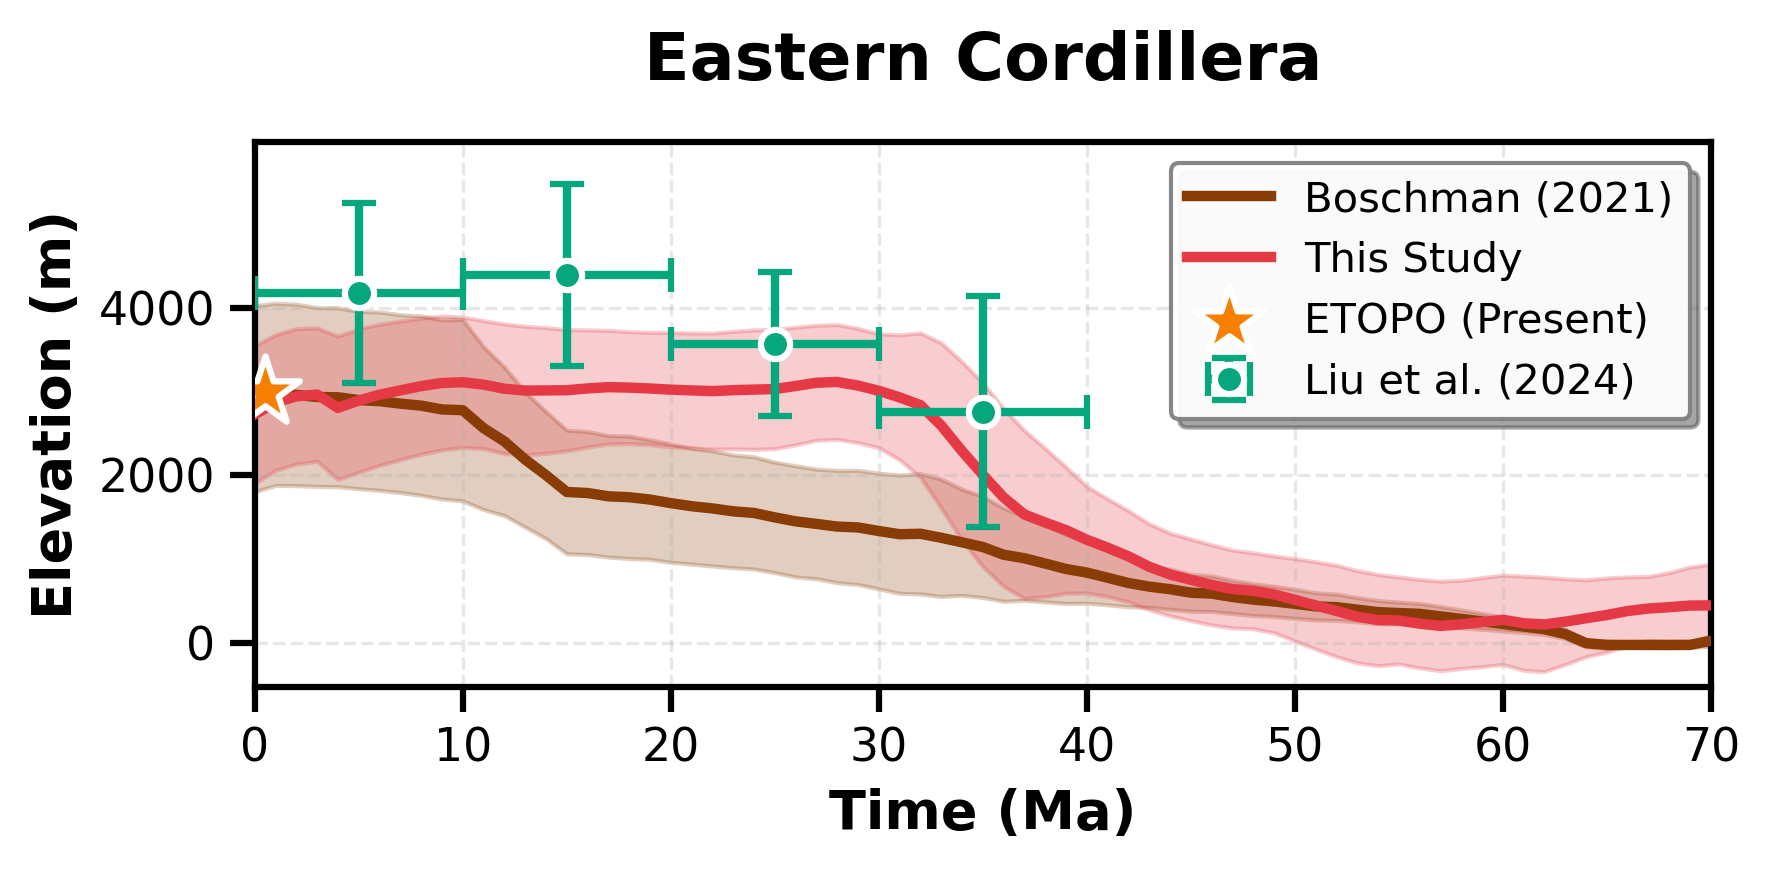

Working on: Western Cordillera
Directory already exists: /Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/Andes/All_comparison


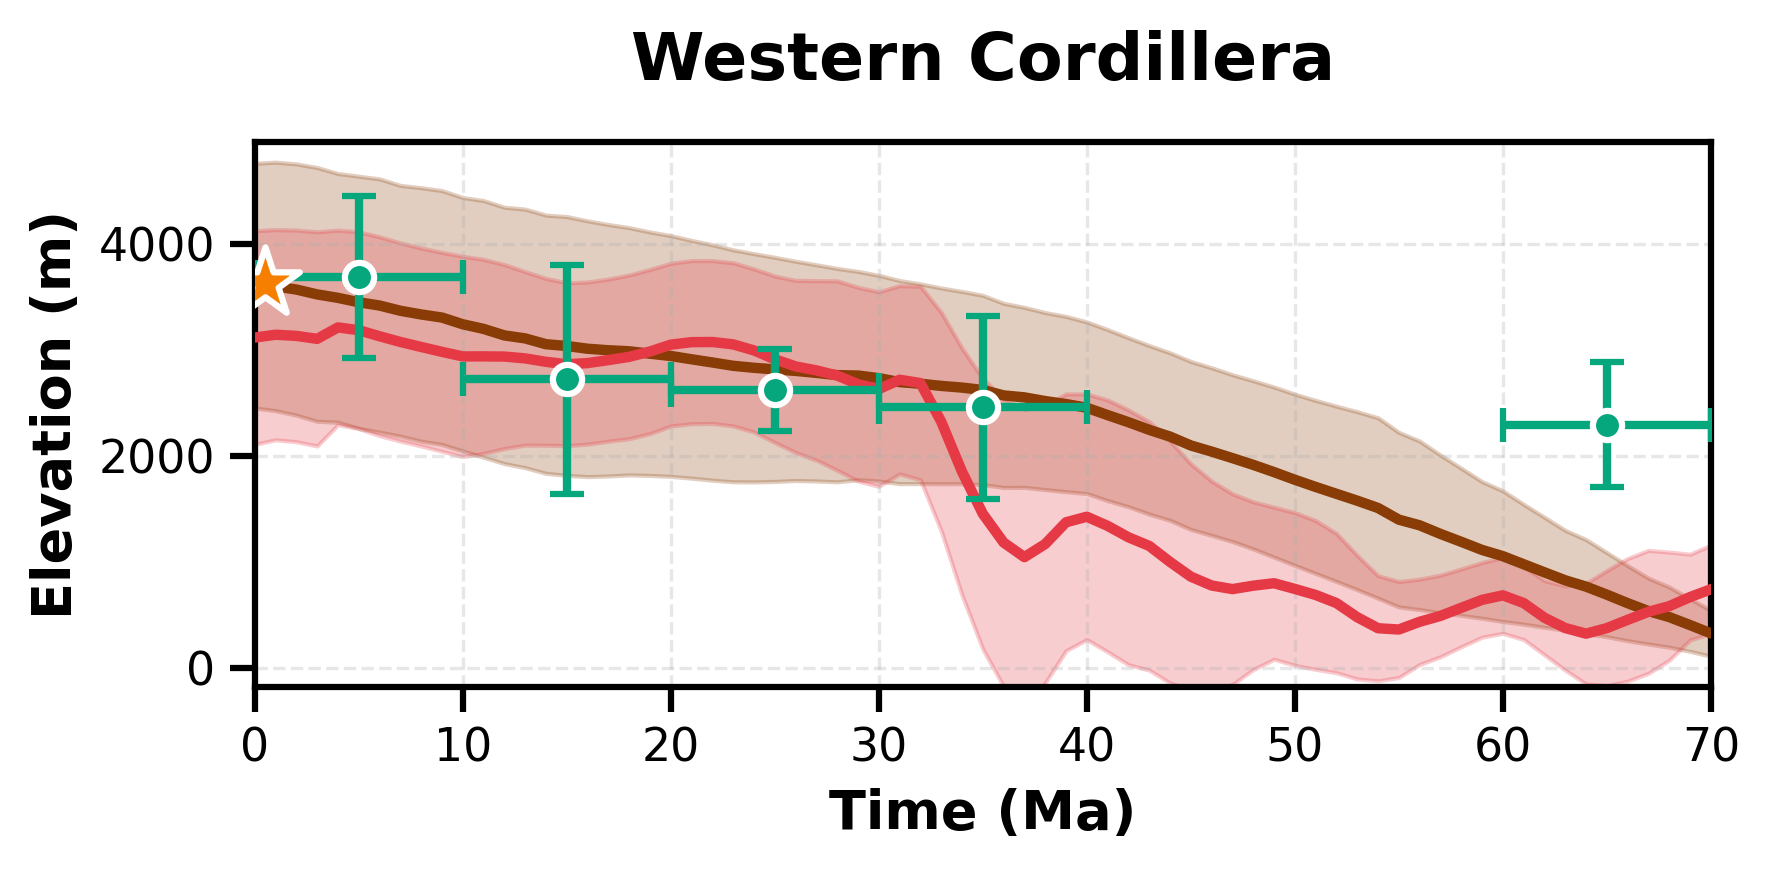

Working on: Precordillera/coastal cordillera/forearc
Directory already exists: /Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/Andes/All_comparison


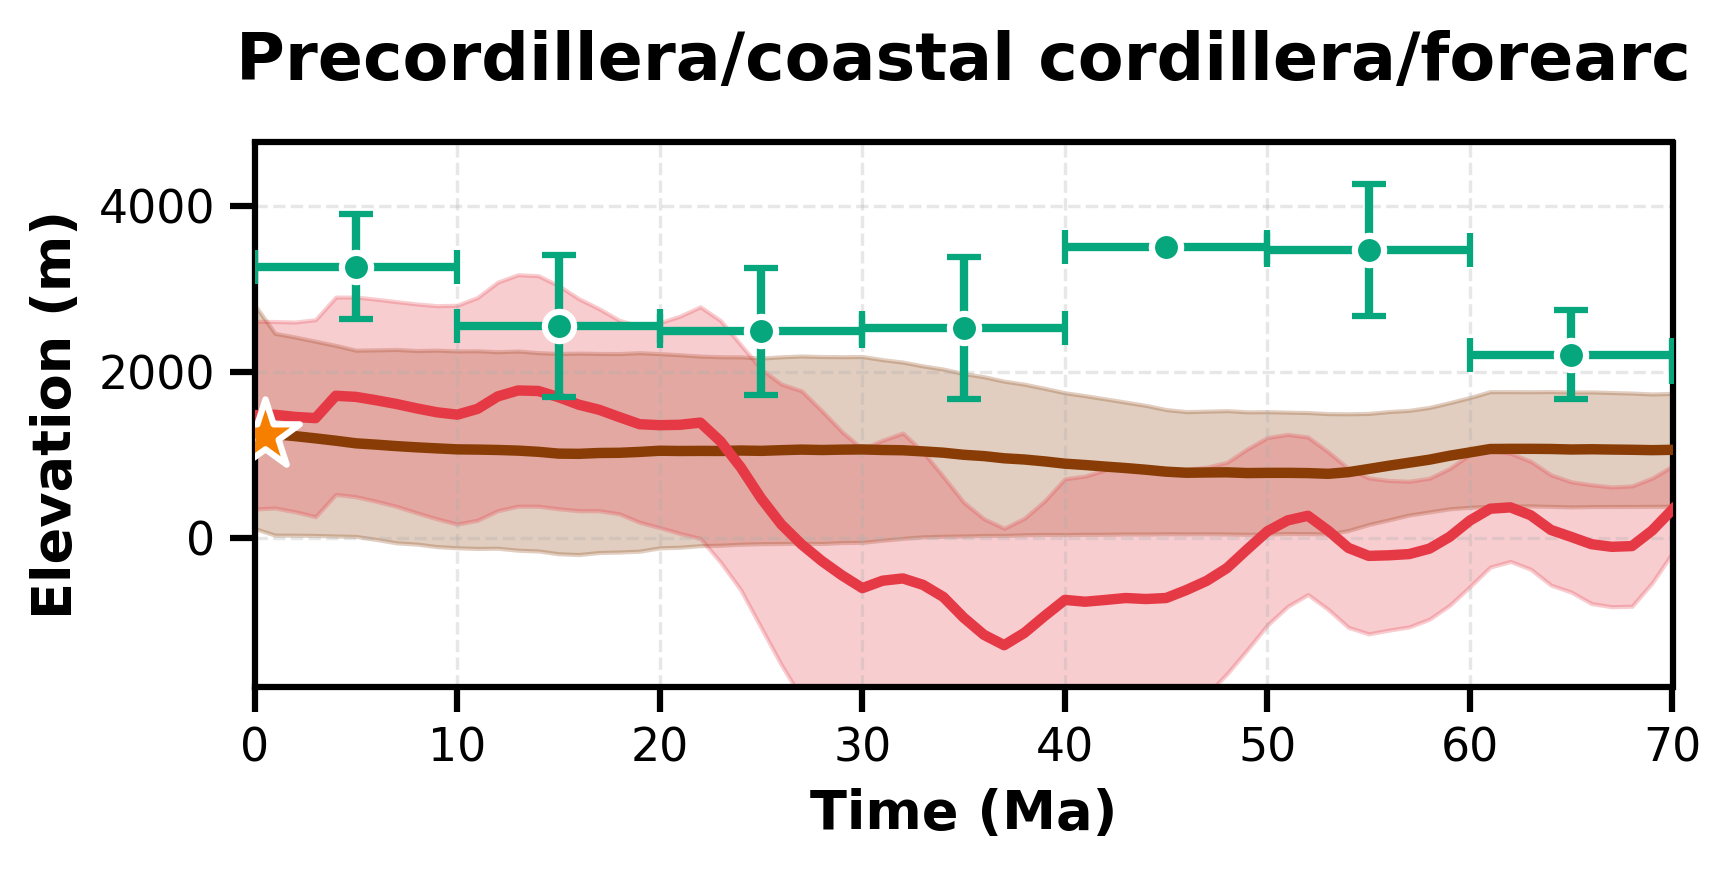

Working on: SubAndes
Directory already exists: /Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/Andes/All_comparison


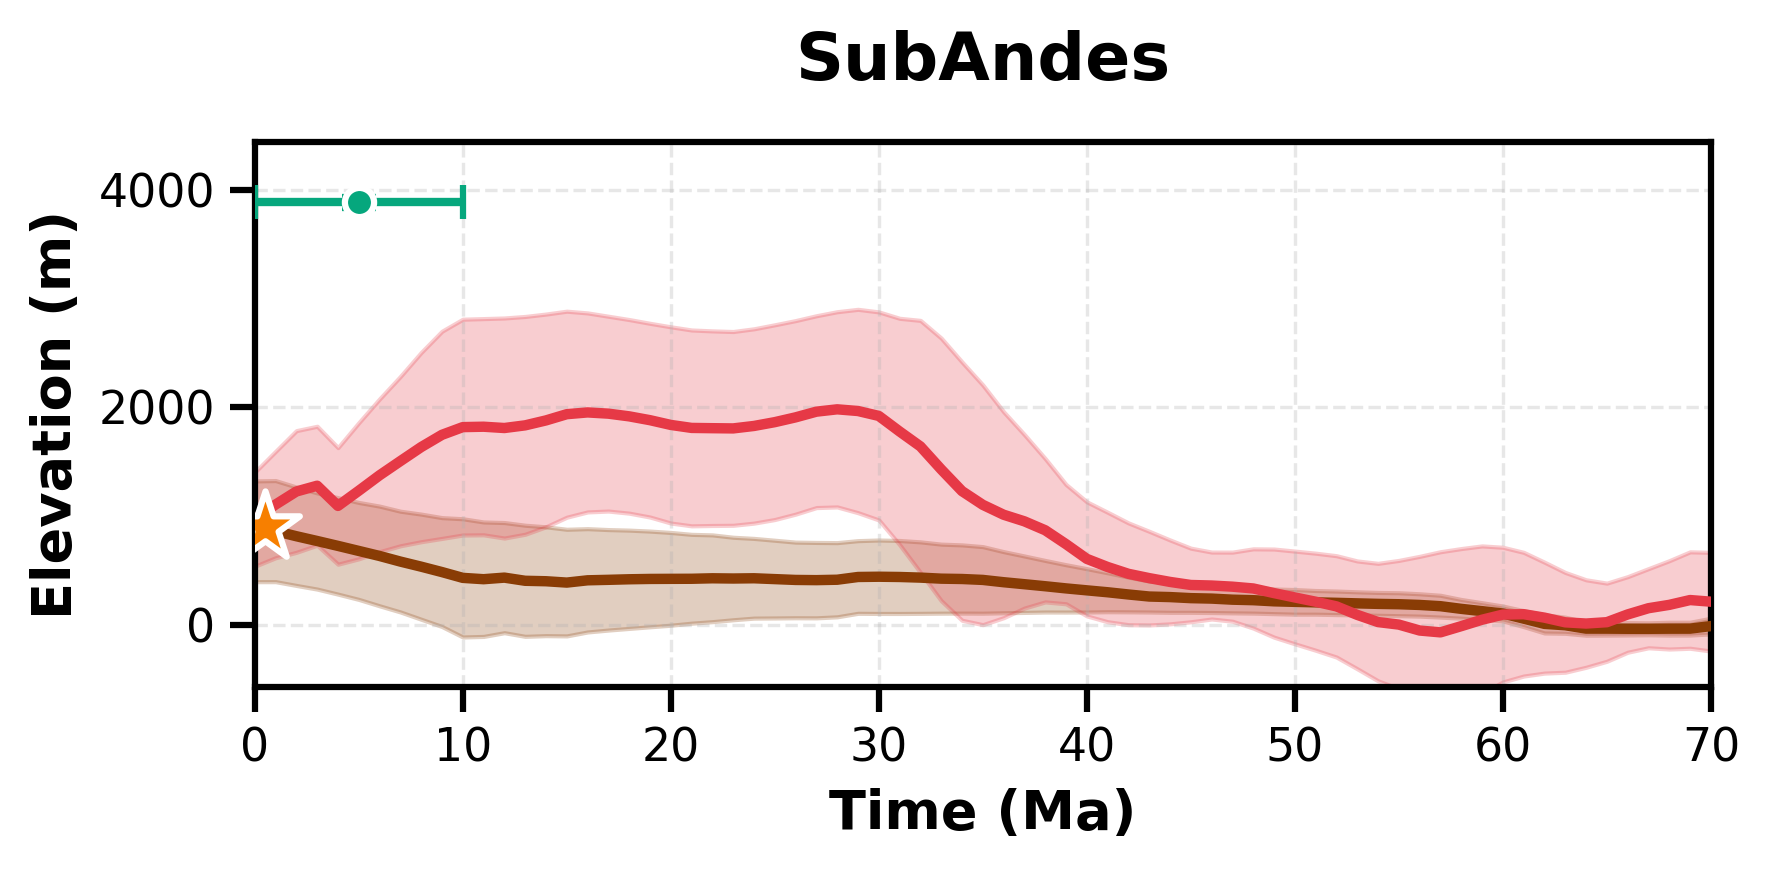

Working on: Frontal Cordillera
Directory already exists: /Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/Andes/All_comparison


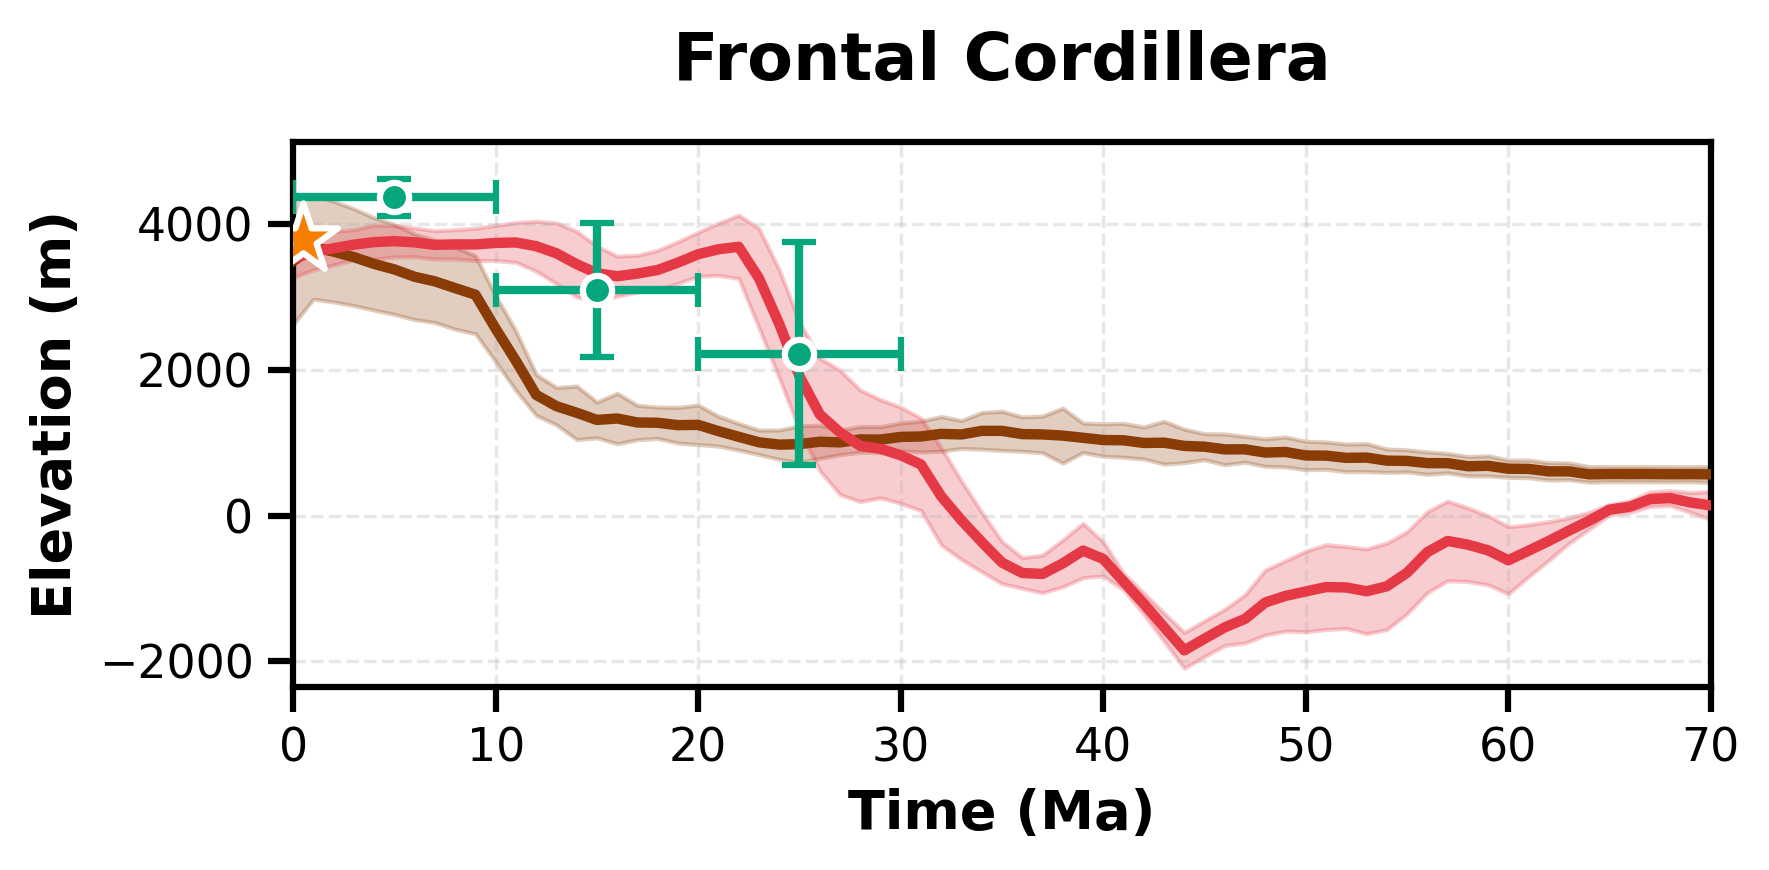

Working on: Principal Cordillera
Directory already exists: /Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/Andes/All_comparison


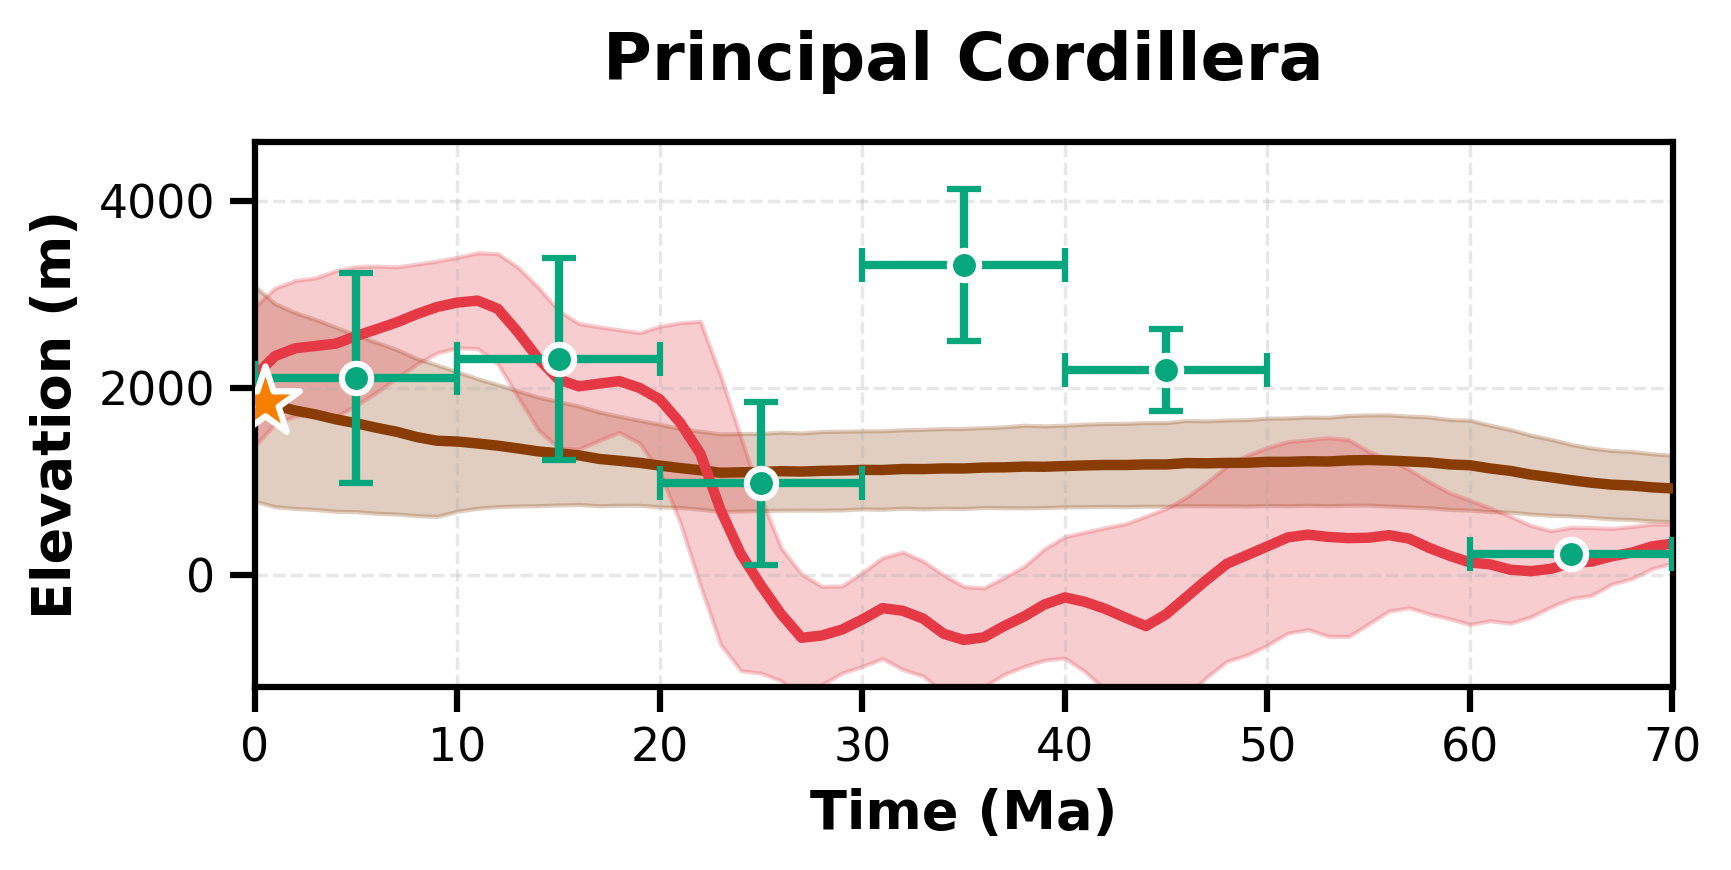

Working on: Principal Cordillera Patagonia
Directory already exists: /Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/Andes/All_comparison


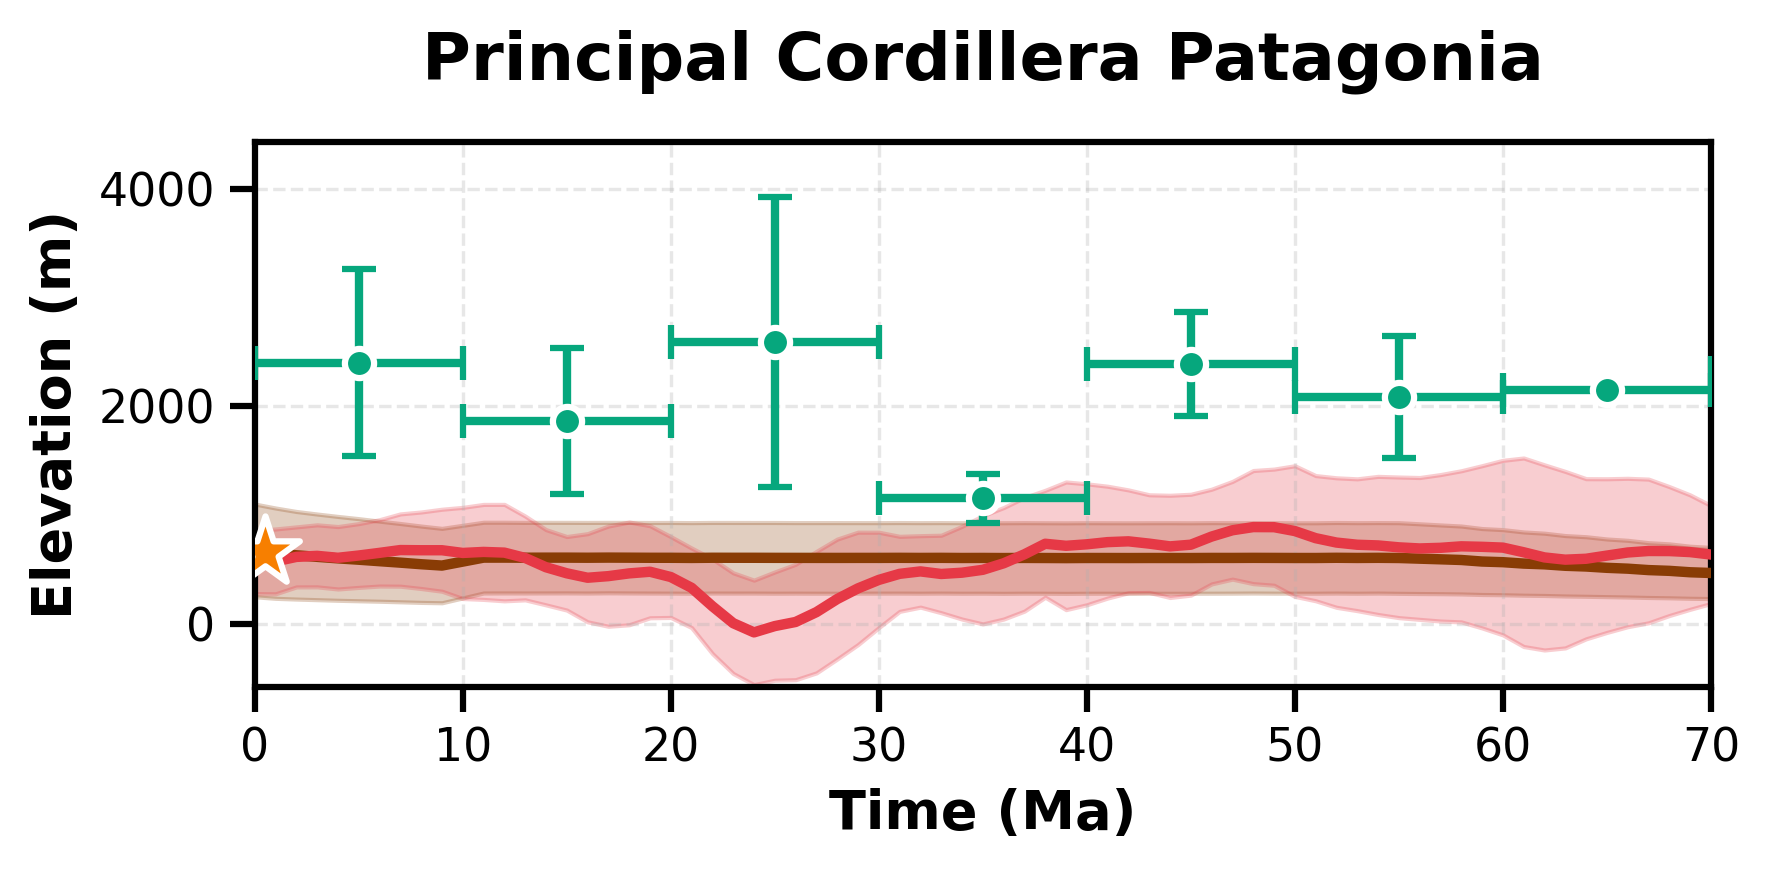

Working on: Eastern Patagonia
Directory already exists: /Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/Andes/All_comparison


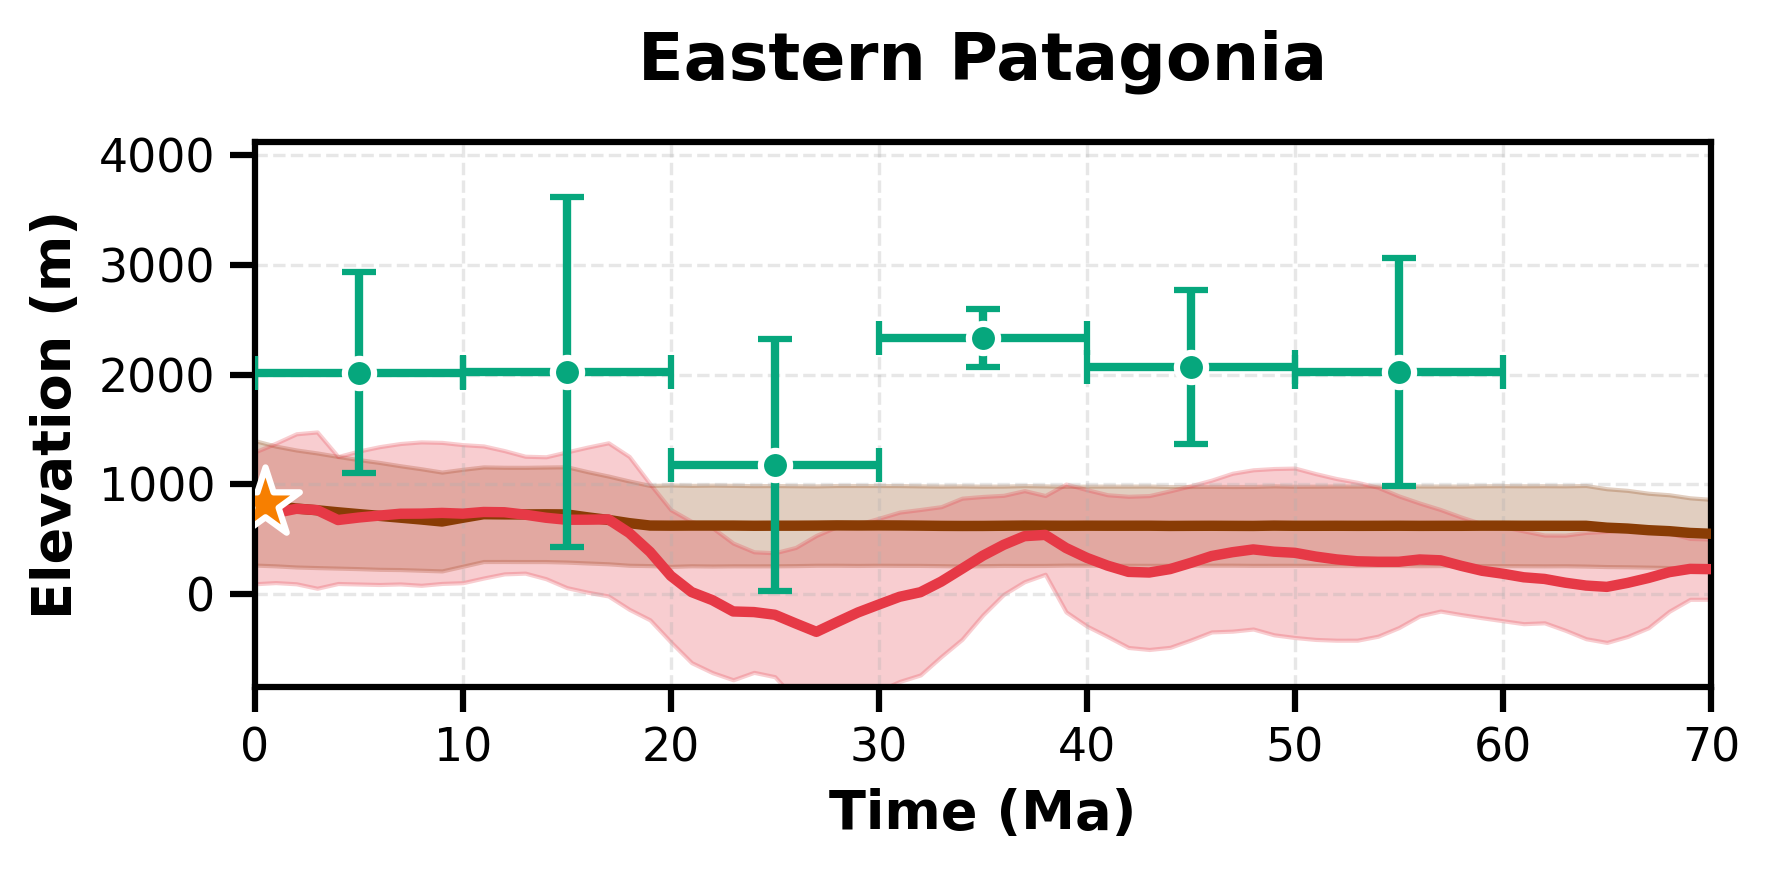

Working on: Northern Andes
Directory already exists: /Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/Andes/All_comparison


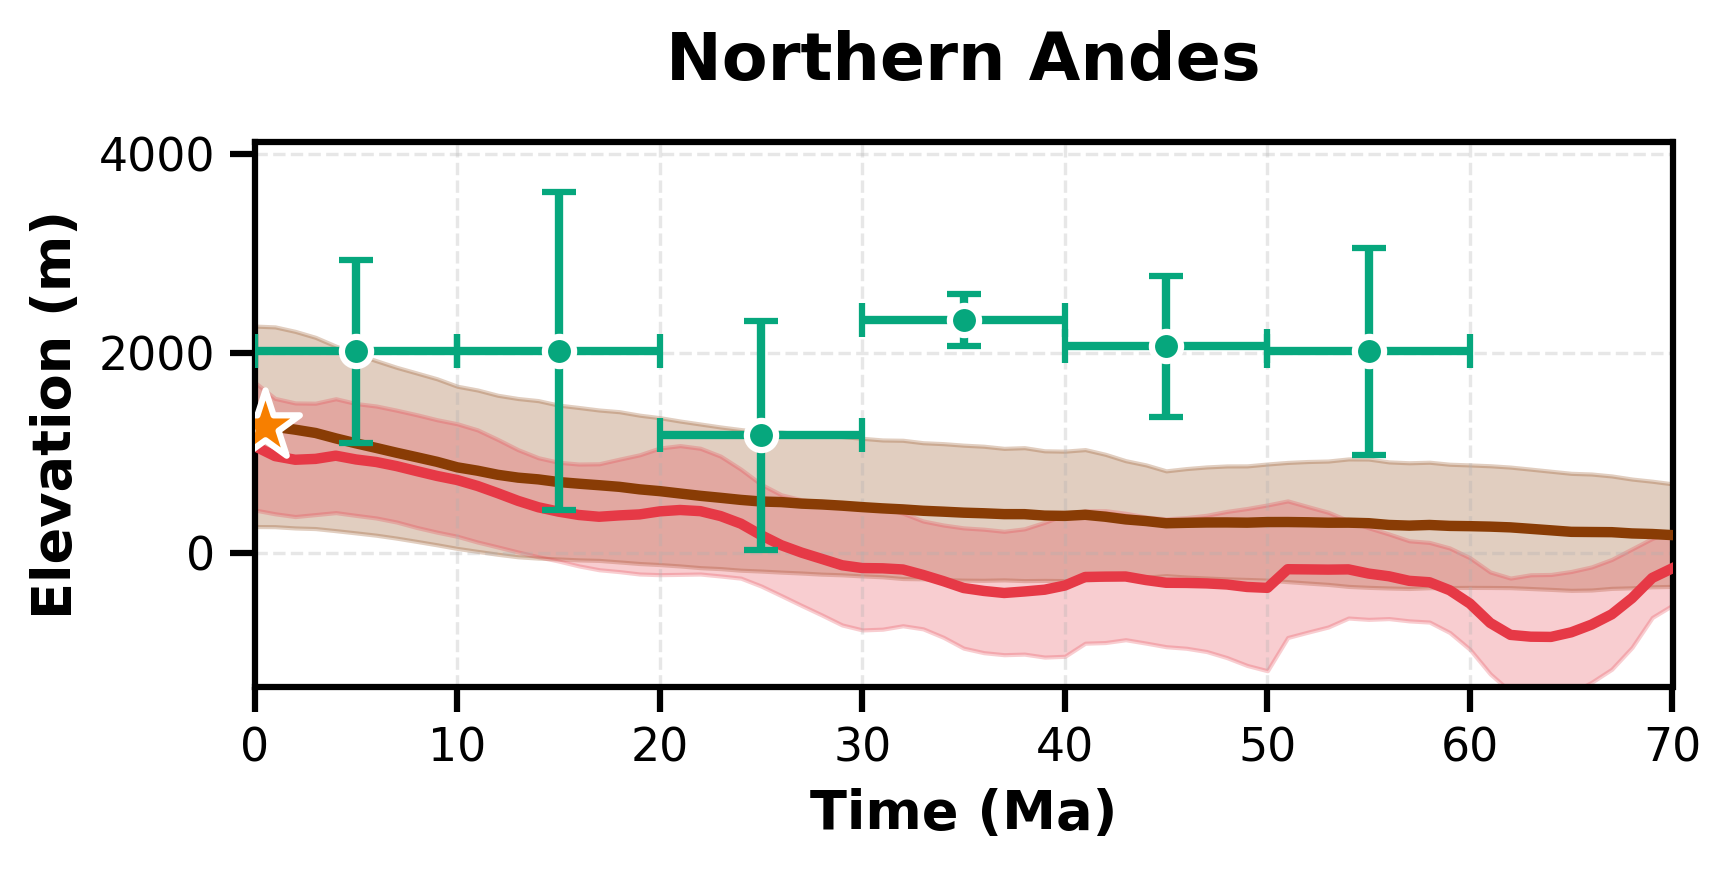

In [27]:
import matplotlib.pyplot as plt
import numpy as np


names = [
      'Eastern Cordillera','Western Cordillera',
    'Precordillera/coastal cordillera/forearc', 'SubAndes',
    'Frontal Cordillera', 'Principal Cordillera',
    'Principal Cordillera Patagonia', 'Eastern Patagonia', 'Northern Andes'
]

i=0
# Filter data for Altiplano
for name in names:
    print(f"Working on: {name}")

    if name=='Northern Andes':
        merged_df_name = merged_df[merged_df['NAME'].isin(northern_andes_name)].copy()
        merged_df_singh_name = merged_df_singh[merged_df_singh['NAME'].isin(northern_andes_name)].copy()
        # clipped_ld_name = clipped_ld[clipped_ld['NAME'] .isin(northern_andes_name)].copy()
        present_day_elevation_name = present_day_elevation[present_day_elevation['NAME'] .isin(northern_andes_name)].copy()
    else:
        merged_df_name = merged_df[merged_df['NAME'] == name].copy()
        merged_df_singh_name = merged_df_singh[merged_df_singh['NAME'] == name].copy()
        clipped_ld_name = clipped_ld[clipped_ld['NAME'] == name].copy()
        present_day_elevation_name = present_day_elevation[present_day_elevation['NAME'] == name].copy()
    # Boschman & Singh stats
    summary_stats_boschman = merged_df_name.groupby("time")["elevation"].agg(["mean", "std"]).reset_index()
    summary_stats_singh = merged_df_singh_name.groupby("time")["elevation"].agg(["mean", "std"]).reset_index()

    # Liu et al. binned stats
    clipped_ld_name = clipped_ld_name[clipped_ld_name["age"] <= 80]
    bins = pd.interval_range(start=0, end=80, freq=10, closed='left')
    clipped_ld_name["age_bin"] = pd.cut(clipped_ld_name["age"], bins=bins)
    summary_stats_lf = clipped_ld_name.groupby("age_bin", observed=True)["Elevation (Median)"].agg(['mean', 'std'])
    summary_stats_lf['age_mid'] = summary_stats_lf.index.map(lambda x: x.mid)

    # Create publication-quality figure
    fig, ax = plt.subplots(figsize=(6, 3), dpi=300)

    # Define professional color palette
    color_boschman = "#893C05"  # Deep blue
    color_singh = '#E63946'     # Red
    color_liu = '#06A77D'       # Teal/green
    color_etopo = '#F77F00'     # Orange

    # Plot Boschman (2021)
    ax.plot(summary_stats_boschman["time"], summary_stats_boschman["mean"], 
            label="Boschman (2021)", color=color_boschman, linewidth=2.5, zorder=3)
    ax.fill_between(
        summary_stats_boschman["time"],
        summary_stats_boschman["mean"] - summary_stats_boschman["std"],
        summary_stats_boschman["mean"] + summary_stats_boschman["std"],
        alpha=0.25, color=color_boschman, zorder=1
    )

    # Plot This Study (Singh)
    ax.plot(summary_stats_singh["time"], summary_stats_singh["mean"], 
            label="This Study", color=color_singh, linewidth=2.5, zorder=3)
    ax.fill_between(
        summary_stats_singh["time"],
        summary_stats_singh["mean"] - summary_stats_singh["std"],
        summary_stats_singh["mean"] + summary_stats_singh["std"],
        alpha=0.25, color=color_singh, zorder=1
    )

    # Plot Liu et al. (2024) with error bars
    ax.errorbar(
        summary_stats_lf['age_mid'],
        summary_stats_lf['mean'],
        yerr=summary_stats_lf['std'],
        xerr=5,
        fmt='o',
        color=color_liu,
        ecolor=color_liu,
        elinewidth=2,
        capsize=4,
        markersize=7,
        markeredgewidth=1.5,
        markeredgecolor='white',
        label="Liu et al. (2024)",
        zorder=4
    )

    # Plot ETOPO present-day elevation
    ax.scatter(0.5, present_day_elevation_name['elevation'].mean(),
            marker='*', color=color_etopo, s=300, 
            edgecolors='white', linewidths=1.5,
            label="ETOPO (Present)", zorder=5)

    # Styling
    ax.set_title(f"{name}", fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel("Time (Ma)", fontsize=13, fontweight='bold')
    ax.set_ylabel("Elevation (m)", fontsize=13, fontweight='bold')

    # Invert x-axis and set limits
    # ax.invert_xaxis()
    ax.set_xlim(70, 0)

    # Calculate appropriate y-limits
    y_min = min(summary_stats_singh["mean"].min(), 
                summary_stats_boschman["mean"].min(),
                (summary_stats_lf['mean'] - summary_stats_lf['std']).min()) - 500
    y_max = max(summary_stats_singh["mean"].max(), 
                summary_stats_boschman["mean"].max(),
                (summary_stats_lf['mean'] + summary_stats_lf['std']).max()) + 500
    ax.set_ylim(y_min, y_max)
    ax.set_xlim(0, 70)

    # Grid
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8, zorder=0)

    # Legend
    if i==0:
        ax.legend(loc='best', frameon=True, shadow=True, 
                fontsize=10, framealpha=0.95, edgecolor='gray')

    # Tick parameters
    ax.tick_params(axis='both', which='major', labelsize=11, 
                width=1.5, length=6)
    ax.tick_params(axis='both', which='minor', width=1, length=3)

    # Spine styling
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    plt.tight_layout()
    i=i+1
    # Save
    create_directory_if_not_exists(f"{DEFAULT_OUTPUT_ANDES}/All_comparison")
    safe_name = re.sub(r'[\\/*?:"<>|]', "_", name)
    plt.savefig(f"{DEFAULT_OUTPUT_ANDES}/All_comparison/Elevation_Comparison_{safe_name}.png", 
            dpi=300, bbox_inches='tight')
    plt.show()

In [62]:
## Plotting Plate Kinematic Model


mantle_dynamics = [
    'Mantle_Temp_202', 'Mantle_Temp_217', 'Mantle_Temp_233',
    'Mantle_Temp_268', 'Mantle_Temp_293', 'Mantle_Temp_323',
    'Mantle_Temp_357', 'Mantle_Temp_396', 'Mantle_Temp_439',
    'Mantle_Temp_487', 'Mantle_Temp_540', 'Mantle_Temp_597',
    'Mantle_Temp_660',

    'Mantle_Velocity_202', 'Mantle_Velocity_217', 'Mantle_Velocity_233',
    'Mantle_Velocity_268', 'Mantle_Velocity_293', 'Mantle_Velocity_323',
    'Mantle_Velocity_357', 'Mantle_Velocity_396', 'Mantle_Velocity_439',
    'Mantle_Velocity_487', 'Mantle_Velocity_540', 'Mantle_Velocity_597',
    'Mantle_Velocity_660'
]

subduction_vol = []
migration_rate=[]
mantle_temp=[]
# Define target subdomains
Names = [
    'Altiplano', 'Western Cordillera', 'Eastern Cordillera',
    'Precordillera/coastal cordillera/forearc', 'SubAndes',
    'Frontal Cordillera', 'Principal Cordillera',
    'Principal Cordillera Patagonia', 'Eastern Patagonia','Puna'
]

for reconstruction_time in range(0, 71,1):
    print(f"Processing {reconstruction_time} Ma")

    # Load shapefile and filter by NAME

    poly = gpd.read_file(f"{DEFAULT_OUTPUT_ANDES}/Boschman2021/Singh++/Reconstructed_Andes_{reconstruction_time}.shp")
    
    poly = poly.to_crs("EPSG:4326")
    poly = poly[poly.NAME.isin(Names)]  # NAME should be predefined list
    try:
        # plate kinematics
        pk=pd.read_parquet(f'{DEFAULT_OUTPUT_CSV}/Prediction_{WINDOW_SIZE}_NEW/Predicted_{MODEL_NAME}_{reconstruction_time}Ma.parquet')
        pk_gdf = gpd.GeoDataFrame(
            pk,
            geometry=gpd.points_from_xy(pk["Longitude"], pk["Latitude"]),
            crs="EPSG:4326"
        )

        # Spatial join: keep only points within polygon(s)
        clipped = gpd.sjoin(pk_gdf, poly, predicate="within", how="inner")
        
        clipped ['Mantle Temperature'] = clipped [[col for col in mantle_dynamics if 'Mantle_Temp' in col]].mean(axis=1)

        # Append to list
        subduction_vol.append(clipped['Subduction Volume Rate'].mean(skipna=True))
        migration_rate.append(clipped['Migration Rate'].mean(skipna=True))
        mantle_temp.append(clipped['Mantle Temperature'].mean(skipna=True))
    except Exception as e:
        print(f"Error processing {reconstruction_time} Ma: {e}")
        subduction_vol.append(np.nan)
        migration_rate.append(np.nan)
        mantle_temp.append(np.nan)
        continue



Processing 0 Ma
Processing 1 Ma
Processing 2 Ma
Processing 3 Ma
Processing 4 Ma
Processing 5 Ma
Processing 6 Ma
Processing 7 Ma
Processing 8 Ma
Processing 9 Ma
Processing 10 Ma
Processing 11 Ma
Processing 12 Ma
Processing 13 Ma
Processing 14 Ma
Processing 15 Ma
Processing 16 Ma
Processing 17 Ma
Processing 18 Ma
Error processing 18 Ma: [Errno 2] No such file or directory: '/Volumes/SatyamData/Merdith1Ga/1Ga_Reconstructions/Paleotopography/CSV/Prediction_25_NEW/Predicted_Merdith1Ga_18Ma.parquet'
Processing 19 Ma
Processing 20 Ma
Processing 21 Ma
Processing 22 Ma
Processing 23 Ma
Processing 24 Ma
Processing 25 Ma
Processing 26 Ma
Processing 27 Ma
Processing 28 Ma
Processing 29 Ma
Processing 30 Ma
Processing 31 Ma
Processing 32 Ma
Processing 33 Ma
Processing 34 Ma
Processing 35 Ma
Processing 36 Ma
Processing 37 Ma
Processing 38 Ma
Processing 39 Ma
Processing 40 Ma
Processing 41 Ma
Processing 42 Ma
Processing 43 Ma
Processing 44 Ma
Processing 45 Ma
Processing 46 Ma
Processing 47 Ma
Processi

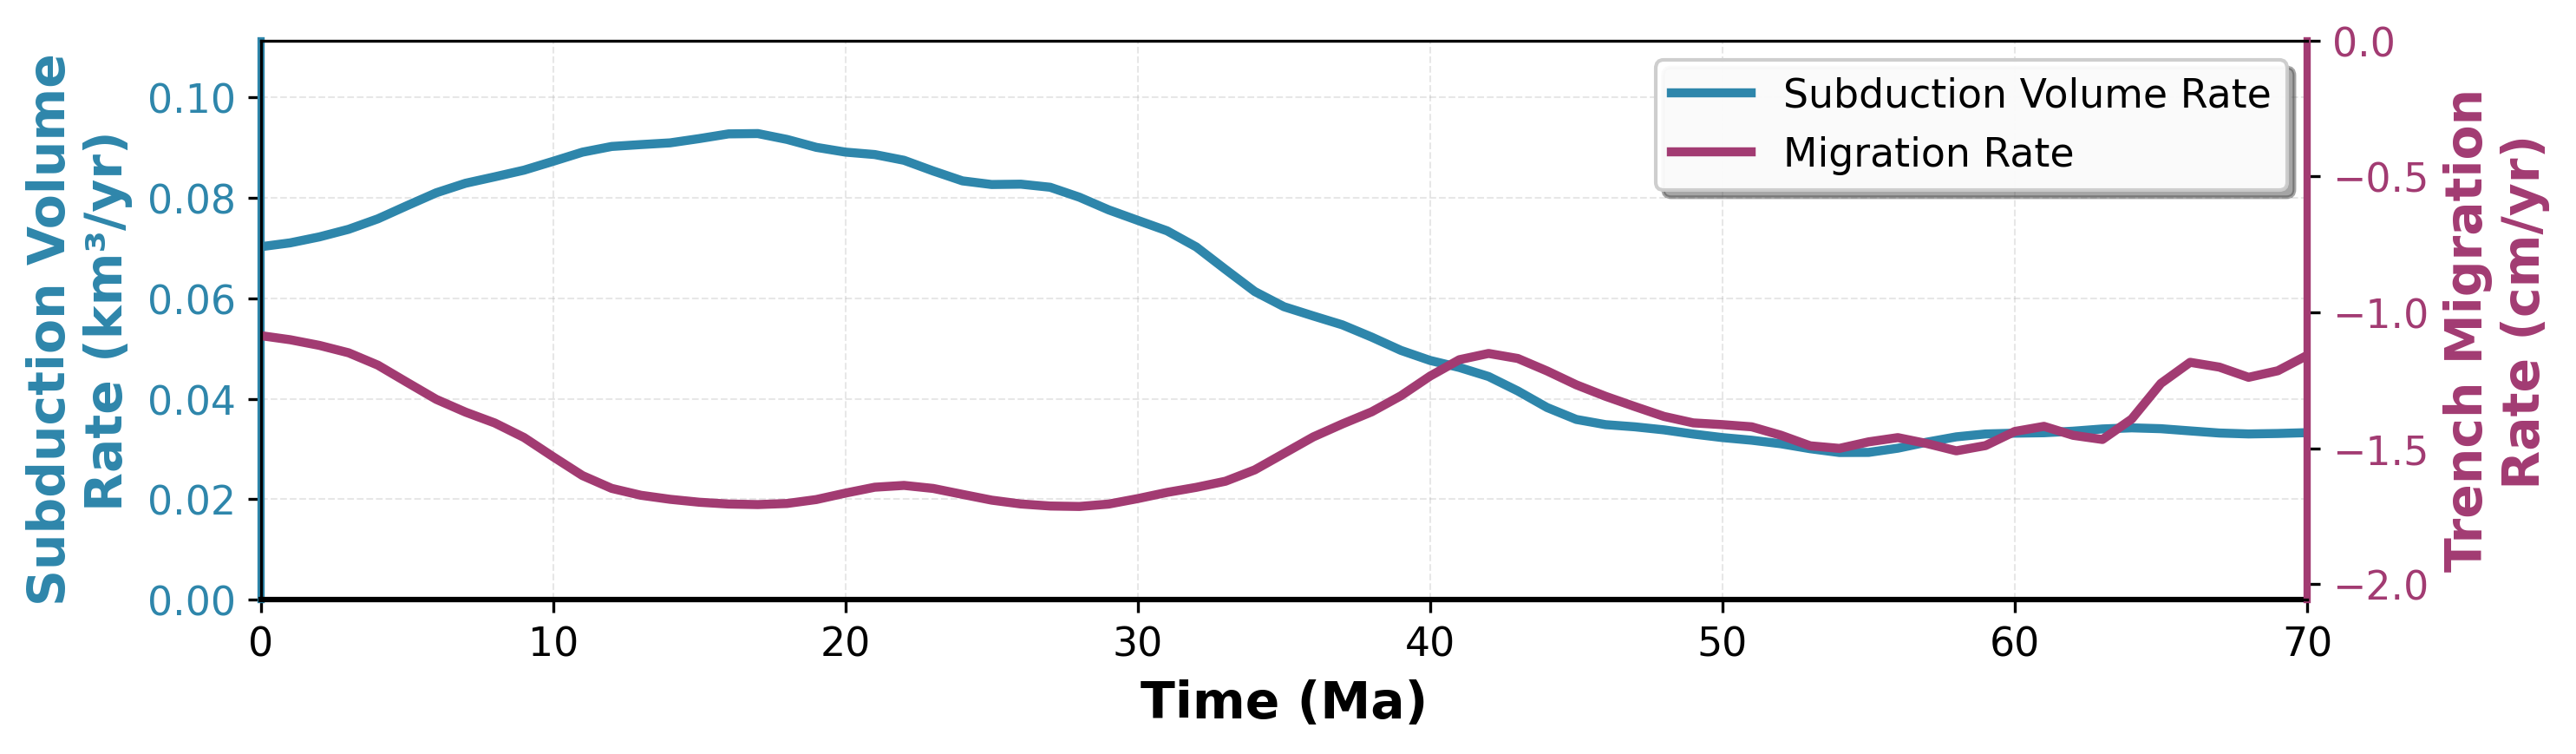

In [95]:
import numpy as np
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import interp1d

# Handle NaN values by interpolation
def fill_nan(data):
    """Fill NaN values using linear interpolation"""
    data = np.array(data)
    nans = np.isnan(data)
    
    if np.all(nans):
        return data  # All NaN, can't interpolate
    
    if np.any(nans):
        # Get indices of non-NaN values
        valid_indices = np.where(~nans)[0]
        valid_values = data[valid_indices]
        
        # Interpolate NaN values
        if len(valid_indices) > 1:
            f = interp1d(valid_indices, valid_values, kind='linear', 
                        fill_value='extrapolate', bounds_error=False)
            nan_indices = np.where(nans)[0]
            data[nan_indices] = f(nan_indices)
    
    return data

# Fill NaN values
subduction_vol_filled = fill_nan(subduction_vol)
migration_rate_filled = fill_nan(migration_rate)

# Smooth the data using Gaussian filter
sigma = 1.5  # Adjust this value for more/less smoothing
subduction_vol_smooth = gaussian_filter1d(subduction_vol_filled, sigma=sigma)
migration_rate_smooth = gaussian_filter1d(migration_rate_filled, sigma=sigma)

# Time array
time = np.array(range(0, 71, 1))

# Create figure with high quality settings
fig, ax1 = plt.subplots(figsize=(10, 3), dpi=300)

# Plot subduction volume on left axis
color1 = '#2E86AB'  # Professional blue
ax1.set_xlabel('Time (Ma)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Subduction Volume \nRate (km³/yr)', fontsize=14, fontweight='bold', color=color1)
line1 = ax1.plot(time, subduction_vol_smooth, linewidth=2.5, color=color1, 
                 label='Subduction Volume Rate', zorder=2)
ax1.tick_params(axis='y', labelcolor=color1, labelsize=11)
ax1.tick_params(axis='x', labelsize=11)
ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# Create twin axis for migration rate
ax2 = ax1.twinx()
color2 = '#A23B72'  # Professional magenta/purple
ax2.set_ylabel('Trench Migration \n Rate (cm/yr)', fontsize=14, fontweight='bold', color=color2)
line2 = ax2.plot(time, 100*migration_rate_smooth, linewidth=2.5, color=color2, 
                 label='Migration Rate', linestyle='-', zorder=2)
ax2.tick_params(axis='y', labelcolor=color2, labelsize=11)
ax2.set_ylim( min(100*migration_rate_smooth)*1.2,0)
ax1.set_ylim(0, max(subduction_vol_smooth)*1.2)
ax1.set_xlim(0, 70)
# Add legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', frameon=True, 
           shadow=True, fontsize=11, framealpha=0.95)

# Styling
ax1.spines['left'].set_color(color1)
ax1.spines['left'].set_linewidth(2)
ax2.spines['right'].set_color(color2)
ax2.spines['right'].set_linewidth(2)
ax1.spines['top'].set_visible(False)
ax1.spines['bottom'].set_linewidth(1.5)

# Add title (optional - often omitted in publications)
# plt.title('Subduction Volume and Migration Rates Over Time', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f"{DEFAULT_OUTPUT_ANDES}/All_comparison/Subduction_Migration_Rates.png", dpi=300)

plt.show()